# Projeto: IMPACTO DOS CRUZAMENTOS DE ESTRADAS SOBRE A CONECTIVIDADE ECOHIDROLÓGICA DE IGARAPÉS AMAZÔNICOS EM PAISAGENS SOB DESMATAMENTO

Autor Principal/Contato Principal: Gabriel Oliveira Ferraz / gabriel.oferraz@usp.br

Autores: FERRAZ, G.O.; LEAL, C.G.; CORREA, K.A.B.; COUTO, T.B.D'A.; MAEOKA, L.T.Y.; BREJAO, G.L.; CARVALHO, D.R.; ALVES FILHO, M.A.; BARLOW, J.; FERRAZ, S.F.B.

# **Parte 1** - Configuração do sistema

In [1]:
%%capture
!pip install geopandas rasterio pandas fiona

In [15]:
# =========================================================
# EXPRESSÕES REGULARES E ESTRUTURAS AUXILIARES
# =========================================================
import re
from collections import defaultdict
from io import StringIO

# =========================================================
# SISTEMA / IO
# =========================================================
import glob
import os

# =========================================================
# REDE / DOWNLOAD
# =========================================================
import requests

# =========================================================
# DADOS TABULARES / NUMÉRICOS
# =========================================================
import numpy as np
import pandas as pd

# =========================================================
# GEOPROCESSAMENTO VETORIAL
# =========================================================
import fiona
import geopandas as gpd
from shapely.geometry import Point, box

# =========================================================
# PROCESSAMENTO RASTER
# =========================================================
import rasterio
from rasterio.features import geometry_mask
from rasterio.mask import mask
from rasterio.warp import Resampling, reproject

# =========================================================
# VISUALIZAÇÃO
# =========================================================
import matplotlib.pyplot as plt

# =========================================================
# AMBIENTE COLAB
# =========================================================
try:
    from google.colab import drive
except ImportError:
    drive = None

In [3]:
# Criar um mapeamento entre valores de classe e seus rótulos e cores correspondentes
class_info = {
    3: {'label': 'Formação Florestal', 'color': '#006400'},
    4: {'label': 'Formação Savânica', 'color': '#00ff00'},
    5: {'label': 'Mangue', 'color': '#687537'},
    49: {'label': 'Restinga Arborizada', 'color': '#6b9932'},
    11: {'label': 'Campo Alagado e Área Pantanosa', 'color': '#45c2a5'},
    12: {'label': 'Formação Campestre', 'color': '#b8af4f'},
    32: {'label': 'Apicum', 'color': '#968c46'},
    29: {'label': 'Afloramento Rochoso', 'color': '#ff8C00'},
    50: {'label': 'Restinga Herbácea', 'color': '#66ffcc'},
    13: {'label': 'Outras Formações não Florestais', 'color': '#bdb76b'},
    15: {'label': 'Pastagem', 'color': '#ffd966'},
    18: {'label': 'Agricultura', 'color': '#e974ed'},
    19: {'label': 'Lavoura Temporária', 'color': '#d5a6bd'},
    39: {'label': 'Soja', 'color': '#c59ff4'},
    20: {'label': 'Cana', 'color': '#c27ba0'},
    40: {'label': 'Arroz', 'color': '#982c9e'},
    62: {'label': 'Algodão', 'color': '#660066'},
    41: {'label': 'Outras Lavouras Temporárias', 'color': '#e787f8'},
    36: {'label': 'Lavoura Perene', 'color': '#f3b4f1'},
    46: {'label': 'Café', 'color': '#cca0d4'},
    47: {'label': 'Citrus', 'color': '#d082de'},
    48: {'label': 'Outras Lavouras Perenes', 'color': '#cd49e4'},
    9: {'label': 'Silvicultura', 'color': '#935132'},
    21: {'label': 'Mosaico de Usos', 'color': '#fff3bf'},
    23: {'label': 'Praia, Duna e Areal', 'color': '#dd7e6b'},
    24: {'label': 'Área Urbanizada', 'color': '#af2a2a'},
    30: {'label': 'Mineração', 'color': '#8a2be2'},
    25: {'label': 'Outras Áreas não Vegetadas', 'color': '#ff99ff'},
    33: {'label': 'Rio, Lago e Oceano', 'color': '#0000ff'},
    31: {'label': 'Aquicultura', 'color': '#29eee4'},
    27: {'label': 'Não observado', 'color': '#D5D5E5'},
}

In [4]:
def obter_shapefile_municipios(uf: str) -> gpd.GeoDataFrame:
    """
    Obtém a malha municipal de uma Unidade da Federação (UF) diretamente da API de malhas do IBGE.

    Esta função consulta a API v4 do IBGE para retornar as geometrias municipais
    de um estado brasileiro, já organizadas em um `GeoDataFrame`.

    Parameters
    ----------
    uf : str
        Sigla da Unidade da Federação com 2 caracteres, por exemplo:
        "SP", "MG", "PR", "RS".

    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame contendo a malha municipal retornada pela API do IBGE.

    Raises
    ------
    ValueError
        Se a UF não for informada corretamente.
    RuntimeError
        Se a API retornar erro HTTP ou se o conteúdo não puder ser lido como camada vetorial.

    Notes
    -----
    - A URL consultada utiliza o parâmetro `intrarregiao=Municipio`.
    - O retorno esperado da API deve ser compatível com leitura via GeoPandas.
    - Dependendo da resposta do IBGE, pode ser necessário ajustar a estratégia
      de leitura em caso de mudança no endpoint ou formato de retorno.
    """
    if not isinstance(uf, str) or len(uf.strip()) != 2:
        raise ValueError("O parâmetro 'uf' deve ser uma string com 2 caracteres, por exemplo: 'SP'.")

    uf = uf.strip().upper()

    url = (
        f"https://servicodados.ibge.gov.br/api/v4/malhas/estados/"
        f"{uf}?formato=application/json&intrarregiao=Municipio"
    )

    try:
        response = requests.get(url, timeout=60)
        response.raise_for_status()
    except requests.RequestException as exc:
        raise RuntimeError(f"Falha na requisição à API do IBGE para UF='{uf}': {exc}") from exc

    try:
        # Converte o texto JSON/GeoJSON retornado em buffer para leitura pelo GeoPandas
        municipios = gpd.read_file(StringIO(response.text))
    except Exception as exc:
        raise RuntimeError(
            f"Não foi possível converter a resposta da API do IBGE em GeoDataFrame para UF='{uf}'."
        ) from exc

    return municipios


def download_mapbiomas(
    output_dir: str = "/content/mapbiomas_completo/",
    ano_inicio: int = 1985,
    ano_fim: int = 2024
) -> None:
    """
    Realiza o download dos rasters anuais de cobertura e uso da terra do MapBiomas.

    A função baixa os arquivos GeoTIFF da Coleção 9 do MapBiomas para um diretório local,
    seguindo o padrão de nomenclatura:
    `brasil_coverage_{ano}.tif`.

    Parameters
    ----------
    output_dir : str, default "/content/mapbiomas_completo/"
        Diretório de saída onde os arquivos serão armazenados.
    ano_inicio : int, default 1985
        Ano inicial do intervalo de download.
    ano_fim : int, default 2023
        Ano final do intervalo de download.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se o intervalo de anos for inválido.

    Notes
    -----
    - Os arquivos são baixados de um bucket público do Google Storage.
    - O download é feito de forma sequencial, ano a ano.
    - Esta função não implementa retentativa automática nem verificação de integridade do arquivo.
    """
    if ano_inicio > ano_fim:
        raise ValueError("'ano_inicio' não pode ser maior que 'ano_fim'.")

    base_url = (
        "https://storage.googleapis.com/mapbiomas-public/"
        "initiatives/brasil/collection_9/lclu/coverage/"
    )

    os.makedirs(output_dir, exist_ok=True)

    for ano in range(ano_inicio, ano_fim + 1):
        file_name = f"brasil_coverage_{ano}.tif"
        url = base_url + file_name
        output_path = os.path.join(output_dir, file_name)

        try:
            response = requests.get(url, timeout=60)

            if response.status_code == 200:
                with open(output_path, "wb") as f:
                    f.write(response.content)
                print(f"✅ Arquivo baixado com sucesso: {file_name}")
            else:
                print(f"❌ Erro no download de {file_name} | HTTP {response.status_code}")

        except requests.RequestException as exc:
            print(f"⚠️ Falha de conexão ao baixar {file_name}: {exc}")

    print("\nDownload concluído.")


def download_file(url: str, save_path: str) -> None:
    """
    Faz o download de um arquivo remoto e salva localmente em disco.

    O download é realizado em modo streaming, reduzindo o consumo de memória
    ao gravar o conteúdo em blocos (`chunks`).

    Parameters
    ----------
    url : str
        URL completa do arquivo a ser baixado.
    save_path : str
        Caminho completo de saída, incluindo nome do arquivo.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se a URL ou o caminho de saída forem inválidos.

    Notes
    -----
    - O diretório de destino é criado automaticamente caso não exista.
    - O tamanho do chunk está configurado em 8192 bytes.
    - Esta função não verifica checksum, hash ou tamanho final do arquivo.
    """
    if not isinstance(url, str) or not url.strip():
        raise ValueError("O parâmetro 'url' deve ser uma string não vazia.")

    if not isinstance(save_path, str) or not save_path.strip():
        raise ValueError("O parâmetro 'save_path' deve ser uma string não vazia.")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()

        with open(save_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    file.write(chunk)

        print(f"✅ Arquivo baixado com sucesso em: {save_path}")

    except requests.RequestException as exc:
        print(f"❌ Falha ao baixar o arquivo: {exc}")


def crop_raster_by_municipality(
    shapefile_path: str,
    raster_path: str,
    output_dir: str,
    municipio: str
) -> str:
    """
    Recorta um raster utilizando a geometria de um município específico.

    A função lê um arquivo vetorial contendo municípios, localiza a feição
    cujo atributo `NM_MUN` corresponda ao nome informado, e usa essa geometria
    para recortar um raster via `rasterio.mask.mask`.

    Parameters
    ----------
    shapefile_path : str
        Caminho para o arquivo vetorial contendo os municípios.
    raster_path : str
        Caminho para o raster a ser recortado.
    output_dir : str
        Diretório onde o raster recortado será salvo.
    municipio : str
        Nome do município exatamente como registrado no atributo `NM_MUN`.

    Returns
    -------
    str
        Caminho completo do raster recortado gerado.

    Raises
    ------
    FileNotFoundError
        Se o shapefile ou o raster não forem encontrados.
    ValueError
        Se o município não existir no arquivo vetorial.

    Notes
    -----
    - A função assume a existência do campo `NM_MUN` na tabela de atributos.
    - Não é realizada reprojeção automática entre shapefile e raster.
      Portanto, ambos devem estar no mesmo SRC/CRS.
    - O nome do arquivo de saída recebe o sufixo `_masked`.
    """
    if not os.path.exists(shapefile_path):
        raise FileNotFoundError(f"Shapefile não encontrado: {shapefile_path}")

    if not os.path.exists(raster_path):
        raise FileNotFoundError(f"Raster não encontrado: {raster_path}")

    os.makedirs(output_dir, exist_ok=True)

    raster_name = os.path.basename(raster_path).replace(".tif", "")
    output_raster_path = os.path.join(
        output_dir,
        f"{raster_name}_{municipio}_masked.tif"
    )

    # Leitura vetorial com Fiona para busca direta da geometria do município
    with fiona.open(shapefile_path, "r") as shapefile:
        municipio_geom = [
            feature["geometry"]
            for feature in shapefile
            if feature["properties"]["NM_MUN"] == municipio
        ]

    if not municipio_geom:
        raise ValueError(f"O município '{municipio}' não foi encontrado no shapefile.")

    # Recorte rasterial baseado na geometria selecionada
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, municipio_geom, crop=True)
        out_meta = src.meta.copy()

    # Atualização dos metadados para o raster recortado
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
    })

    with rasterio.open(output_raster_path, "w", **out_meta) as dest:
        dest.write(out_image)

    print(f"✅ Raster recortado salvo em: {output_raster_path}")
    return output_raster_path


def recortar_mapbiomas_por_roi(
    gdf_shapefile: gpd.GeoDataFrame,
    input_dir: str = "/content/mapbiomas_completo/",
    output_dir: str = "/content/ROI/",
    ano_inicio: int = 1985,
    ano_fim: int = 2024,
    margem: float = 0.008,
    plotar: bool = True
) -> None:
    """
    Recorta os rasters anuais do MapBiomas com base no retângulo envolvente
    (bounding box expandido) de uma região de interesse.

    A função calcula o envelope espacial do `GeoDataFrame` de entrada,
    aplica uma margem adicional em unidades do CRS, cria um polígono retangular
    e recorta cada raster anual do intervalo especificado.

    Parameters
    ----------
    gdf_shapefile : geopandas.GeoDataFrame
        GeoDataFrame contendo a região de interesse (ROI).
    input_dir : str, default "/content/mapbiomas_completo/"
        Diretório onde estão armazenados os rasters anuais originais.
    output_dir : str, default "/content/ROI/"
        Diretório de saída para os rasters recortados.
    ano_inicio : int, default 1985
        Ano inicial do processamento.
    ano_fim : int, default 2024
        Ano final do processamento.
    margem : float, default 0.008
        Valor adicional aplicado aos limites do bounding box.
        A interpretação depende do CRS do `gdf_shapefile`. Em CRS geográfico,
        normalmente representa graus.
    plotar : bool, default True
        Se `True`, plota a ROI original e o bounding box expandido.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se o GeoDataFrame estiver vazio ou o intervalo de anos for inválido.

    Notes
    -----
    - O recorte é feito sobre o bounding box expandido, e não sobre a geometria
      original detalhada da ROI.
    - Não há reprojeção automática entre ROI e raster.
    - Os arquivos de saída seguem o padrão: `mb-brazil-v9-{ano}.tif`.
    """
    if gdf_shapefile is None or gdf_shapefile.empty:
        raise ValueError("O 'gdf_shapefile' está vazio ou inválido.")

    if ano_inicio > ano_fim:
        raise ValueError("'ano_inicio' não pode ser maior que 'ano_fim'.")

    os.makedirs(output_dir, exist_ok=True)

    # total_bounds retorna: [minx, miny, maxx, maxy]
    extensao = gdf_shapefile.total_bounds

    # Expansão manual do bounding box
    minx = extensao[0] - margem
    miny = extensao[1] - margem
    maxx = extensao[2] + margem
    maxy = extensao[3] + margem

    quadrado_geom = box(minx, miny, maxx, maxy)

    gdf_quadrado = gpd.GeoDataFrame(
        geometry=[quadrado_geom],
        crs=gdf_shapefile.crs
    )

    # Visualização opcional para inspeção espacial do recorte
    if plotar:
        ax = gdf_shapefile.plot(edgecolor="red", facecolor="none", figsize=(10, 10))
        gdf_quadrado.plot(ax=ax, edgecolor="blue", facecolor="none")
        plt.show()

    for ano in range(ano_inicio, ano_fim + 1):
        file_name = f"brasil_coverage_{ano}.tif"
        input_path = os.path.join(input_dir, file_name)

        if not os.path.exists(input_path):
            print(f"⚠️ Arquivo não encontrado: {file_name}")
            continue

        with rasterio.open(input_path) as src:
            out_image, out_transform = mask(
                src,
                gdf_quadrado.geometry,
                crop=True
            )

            out_meta = src.meta.copy()
            out_meta.update({
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })

            output_path = os.path.join(output_dir, f"mb-brazil-v9-{ano}.tif")

            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(out_image)

        print(f"✅ Raster recortado com sucesso: {output_path}")

    print("\nProcesso concluído.")


def contar_ocorrencias_classe_rasters(
    input_folder: str,
    output_raster: str,
    classe: int = 33
):
    """
    Calcula a contagem acumulada de ocorrência de uma classe específica
    ao longo de múltiplos rasters anuais.

    Para cada pixel, a função soma o número de vezes em que o valor do pixel
    é igual à classe especificada em todos os rasters da pasta.

    Parameters
    ----------
    input_folder : str
        Caminho para a pasta contendo os rasters (.tif).
    output_raster : str
        Caminho completo do raster de saída.
    classe : int, default 33
        Valor da classe a ser contabilizada.

    Returns
    -------
    numpy.ndarray
        Matriz 2D contendo a contagem acumulada por pixel.

    Raises
    ------
    FileNotFoundError
        Se a pasta não existir ou não contiver arquivos .tif.
    ValueError
        Se os rasters não tiverem dimensões consistentes.

    Notes
    -----
    - Todos os rasters devem possuir mesma resolução, extensão e CRS.
    - A contagem é feita pixel a pixel.
    - O raster final representa a frequência temporal da classe.
    """

    import os
    import numpy as np
    import rasterio

    # ---------------------------------------------------
    # 1) Validar pasta e listar rasters
    # ---------------------------------------------------
    if not os.path.exists(input_folder):
        raise FileNotFoundError(f"Pasta não encontrada: {input_folder}")

    rasters = sorted([
        os.path.join(input_folder, f)
        for f in os.listdir(input_folder)
        if f.endswith(".tif")
    ])

    if len(rasters) == 0:
        raise FileNotFoundError(f"Nenhum arquivo .tif encontrado em: {input_folder}")

    # ---------------------------------------------------
    # 2) Inicializar variáveis
    # ---------------------------------------------------
    accumulated_count = None
    meta = None
    shape_ref = None

    # ---------------------------------------------------
    # 3) Loop pelos rasters
    # ---------------------------------------------------
    for raster_path in rasters:
        with rasterio.open(raster_path) as src:
            data = src.read(1)

            # Verificar consistência espacial
            if shape_ref is None:
                shape_ref = data.shape
            elif data.shape != shape_ref:
                raise ValueError(f"Raster com dimensão inconsistente: {raster_path}")

            # Criar máscara da classe
            class_mask = (data == classe)

            # Inicializar matriz acumulada
            if accumulated_count is None:
                accumulated_count = np.zeros_like(data, dtype=np.int32)
                meta = src.meta.copy()

            # Somar ocorrência
            accumulated_count += class_mask.astype(np.int32)

    # ---------------------------------------------------
    # 4) Atualizar metadados
    # ---------------------------------------------------
    meta.update({
        "dtype": "int32",
        "count": 1,
        "compress": "lzw"
    })

    # Criar diretório de saída se não existir
    os.makedirs(os.path.dirname(output_raster), exist_ok=True)

    # ---------------------------------------------------
    # 5) Salvar raster final
    # ---------------------------------------------------
    with rasterio.open(output_raster, "w", **meta) as dest:
        dest.write(accumulated_count, 1)

    print(f"✅ Raster de contagem criado com sucesso: {output_raster}")

    return accumulated_count


def is_pure_pixel(r: int, c: int, data) -> bool:
    """
    Verifica se um pixel é "puro" considerando uma vizinhança 3x3.

    Um pixel é considerado puro quando todos os seus 8 vizinhos
    imediatos possuem exatamente o mesmo valor do pixel central.

    Parameters
    ----------
    r : int
        Índice da linha do pixel central.
    c : int
        Índice da coluna do pixel central.
    data : numpy.ndarray
        Matriz 2D contendo os valores do raster.

    Returns
    -------
    bool
        True se o pixel for puro dentro da janela 3x3.
        False se estiver na borda do raster ou se qualquer vizinho
        tiver valor diferente do pixel central.

    Notes
    -----
    - Pixels localizados na borda do raster retornam False,
      pois não possuem uma vizinhança 3x3 completa.
    - A função compara apenas igualdade exata entre valores.
    """
    rows, cols = data.shape
    valor_central = data[r, c]

    # Percorre a vizinhança 3x3 ao redor do pixel central
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:

            # Ignora o próprio pixel central
            if dr == 0 and dc == 0:
                continue

            nr, nc = r + dr, c + dc

            # Pixels na borda não possuem kernel 3x3 completo
            if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
                return False

            # Se qualquer vizinho tiver valor diferente, o pixel não é puro
            if data[nr, nc] != valor_central:
                return False

    return True


def categorize_class(value: int | float) -> str | None:
    """
    Categoriza um valor em classes de idade de floresta secundária.

    Parameters
    ----------
    value : int or float
        Valor numérico a ser classificado.

    Returns
    -------
    str or None
        Retorna:
        - 'Florestas Secundárias Novas (5 a 15 anos)' para valores entre 5 e 15
        - 'Florestas Secundárias (>15 anos)' para valores maiores que 15
        - None para valores fora dessas faixas

    Notes
    -----
    - O intervalo de 5 a 15 é inclusivo.
    - Valores menores que 5 não recebem categoria.
    """
    if 5 <= value <= 15:
        return "Florestas Secundárias Novas (5 a 15 anos)"
    elif value > 15:
        return "Florestas Secundárias (>15 anos)"

    return None


def plotar_distribuicao_uso_solo_mapbiomas(
    caminho_imagens="/content/ROI/",
    class_info=None,
    figsize=(10, 7),
    bar_width=0.9,
    legenda_ncol=4,
    excluir_classes=None
):
    """
    Calcula a frequência de pixels por classe em rasters anuais do MapBiomas e
    gera um gráfico de barras empilhadas com a distribuição percentual de uso e
    ocupação do solo ao longo dos anos.

    Parameters
    ----------
    caminho_imagens : str, default "/content/ROI/"
        Diretório contendo os arquivos raster `.tif` já recortados.
    class_info : dict
        Dicionário com a descrição das classes do MapBiomas.
        Estrutura esperada:
        {
            codigo_classe: {
                "label": "Nome da classe",
                "color": "#RRGGBB"
            },
            ...
        }
    figsize : tuple, default (10, 7)
        Tamanho da figura no formato (largura, altura).
    bar_width : float, default 0.9
        Largura das barras do gráfico empilhado.
    legenda_ncol : int, default 4
        Número de colunas da legenda.
    excluir_classes : list or None, default None
        Lista de classes a serem removidas da análise.
        Exemplo: [0]

    Returns
    -------
    df_export : pandas.DataFrame
        DataFrame contendo as frequências absolutas de pixels por classe e por arquivo.
    class_percentages : dict
        Dicionário com os percentuais por classe ao longo dos anos.
    fig : matplotlib.figure.Figure
        Objeto Figure do matplotlib.
    ax : matplotlib.axes.Axes
        Objeto Axes do matplotlib.

    Raises
    ------
    ValueError
        Se `class_info` não for informado.
    FileNotFoundError
        Se nenhum raster `.tif` for encontrado no diretório informado.

    Notes
    -----
    - O ano é extraído do nome do arquivo usando a primeira ocorrência de 4 dígitos.
    - O cálculo percentual é feito com base no total de pixels válidos por ano.
    - Apenas classes presentes em `class_info` são usadas no gráfico.
    - Classes ausentes em um ano recebem valor zero.
    """
    if class_info is None:
        raise ValueError("O parâmetro 'class_info' deve ser informado.")

    if excluir_classes is None:
        excluir_classes = [0]

    # ---------------------------------------------------
    # 1) Listar arquivos raster
    # ---------------------------------------------------
    arquivos_imagens = glob.glob(os.path.join(caminho_imagens, "*.tif"))

    if len(arquivos_imagens) == 0:
        raise FileNotFoundError(f"Nenhum arquivo '.tif' encontrado em: {caminho_imagens}")

    # ---------------------------------------------------
    # 2) Calcular frequências de pixels por raster
    # ---------------------------------------------------
    pixel_frequencies = {}

    for arquivo in arquivos_imagens:
        with rasterio.open(arquivo) as src:
            raster_data = src.read(1)

            # Frequência de cada valor de pixel
            unique, counts = np.unique(raster_data, return_counts=True)
            freq_dict = dict(zip(unique, counts))

            pixel_frequencies[arquivo] = freq_dict

    # ---------------------------------------------------
    # 3) Converter para DataFrame
    # ---------------------------------------------------
    df = pd.DataFrame.from_dict(pixel_frequencies, orient="index")
    df = df.fillna(0).astype(int)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "filename"}, inplace=True)

    # Remover classes indesejadas, se existirem
    for classe in excluir_classes:
        if classe in df.columns:
            df = df.drop(columns=[classe])

        # também verifica string, caso a coluna venha como texto
        if str(classe) in df.columns:
            df = df.drop(columns=[str(classe)])

    # ---------------------------------------------------
    # 4) Extrair ano do nome do arquivo
    # ---------------------------------------------------
    df["year"] = df["filename"].str.extract(r"(\d{4})").astype(int)

    # Ordenar por ano
    df = df.sort_values("year").reset_index(drop=True)

    df_export = df.copy()

    # ---------------------------------------------------
    # 5) Criar estrutura de contagem por classe
    # ---------------------------------------------------
    anos = sorted(df["year"].unique())
    n_anos = len(anos)
    ano_para_indice = {ano: i for i, ano in enumerate(anos)}

    class_counts = {
        value["label"]: np.zeros(n_anos, dtype=float)
        for value in class_info.values()
    }

    # ---------------------------------------------------
    # 6) Preencher contagens por classe e por ano
    # ---------------------------------------------------
    for _, row in df.iterrows():
        year_index = ano_para_indice[row["year"]]

        for class_value in class_info.keys():
            # suporta colunas inteiras ou string
            if class_value in row.index:
                class_counts[class_info[class_value]["label"]][year_index] += row[class_value]
            elif str(class_value) in row.index:
                class_counts[class_info[class_value]["label"]][year_index] += row[str(class_value)]

    # ---------------------------------------------------
    # 7) Calcular total por ano
    # ---------------------------------------------------
    total_area_per_year = np.sum(list(class_counts.values()), axis=0)

    # Evitar divisão por zero
    total_area_per_year = np.where(total_area_per_year == 0, np.nan, total_area_per_year)

    # ---------------------------------------------------
    # 8) Calcular percentuais por classe
    # ---------------------------------------------------
    class_percentages = {}
    for label, counts in class_counts.items():
        if np.any(counts > 0):
            class_percentages[label] = (counts / total_area_per_year) * 100

    # ---------------------------------------------------
    # 9) Plotar gráfico de barras empilhadas
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    bar_positions = np.arange(len(anos))
    bottom = np.zeros(len(anos), dtype=float)

    for label, counts in class_percentages.items():
        # Encontrar a cor da classe a partir do label
        color = [
            class_info[class_value]["color"]
            for class_value in class_info
            if class_info[class_value]["label"] == label
        ][0]

        ax.bar(
            bar_positions,
            counts,
            width=bar_width,
            label=label,
            bottom=bottom,
            color=color,
            edgecolor="black",
            linewidth=0.3
        )

        bottom += counts

    # ---------------------------------------------------
    # 10) Formatação final
    # ---------------------------------------------------
    ax.set_xlabel("Período (Ano)", fontsize=9, fontweight="bold")
    ax.set_ylabel("Uso e Ocupação do Solo (%)", fontsize=10, fontweight="bold")
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(anos, rotation=90)
    ax.set_ylim(0, 100)

    ax.legend(
        title="Classes de Uso",
        fontsize=8,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=legenda_ncol
    )

    ax.set_title("Distribuição de Uso do Solo ao Longo dos Anos", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

    return df_export, class_percentages, fig, ax


def gerar_recortes_mapbiomas_por_bacia(
    gdf_base: gpd.GeoDataFrame,
    id_col: str,
    input_dir: str = "/content/mapbiomas_completo/",
    output_dir: str = "/content/ROI/",
    ano_inicio: int = 1985,
    ano_fim: int = 2023,
    plotar: bool = False,
    all_touched: bool = False
) -> None:
    """
    Gera recortes anuais do MapBiomas para cada unidade espacial contida em um
    GeoDataFrame, utilizando a geometria real de cada feição.

    Para cada valor único da coluna identificadora (`id_col`), a função seleciona
    as geometrias correspondentes e recorta os rasters anuais do MapBiomas no
    intervalo informado, salvando um arquivo por unidade e por ano.

    Parameters
    ----------
    gdf_base : geopandas.GeoDataFrame
        GeoDataFrame contendo as feições espaciais de interesse.
    id_col : str
        Nome da coluna identificadora da unidade espacial.
    input_dir : str, default "/content/mapbiomas_completo/"
        Diretório contendo os rasters anuais originais do MapBiomas.
    output_dir : str, default "/content/ROI/"
        Diretório de saída onde os rasters recortados serão salvos.
    ano_inicio : int, default 1985
        Ano inicial do processamento.
    ano_fim : int, default 2024
        Ano final do processamento.
    plotar : bool, default False
        Se `True`, plota a geometria da unidade antes do recorte.
    all_touched : bool, default False
        Parâmetro repassado para `rasterio.mask.mask`.
        Quando `True`, inclui todos os pixels tocados pela geometria.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se o GeoDataFrame estiver vazio, se a coluna identificadora não existir,
        ou se o intervalo de anos for inválido.

    Notes
    -----
    - O recorte é feito com a geometria real da feição, e não com bounding box.
    - Não é realizada reprojeção automática entre vetor e raster.
    - O nome dos arquivos de saída segue o padrão:
      `mb-brazil-v9-{unidade_id}-{ano}.tif`.
    """
    # Verifica se o GeoDataFrame de entrada existe e possui feições
    if gdf_base is None or gdf_base.empty:
        raise ValueError("O GeoDataFrame de entrada está vazio.")

    # Verifica se a coluna identificadora informada existe no GeoDataFrame
    if id_col not in gdf_base.columns:
        raise ValueError(f"A coluna '{id_col}' não existe no GeoDataFrame.")

    # Garante que o intervalo de anos esteja correto
    if ano_inicio > ano_fim:
        raise ValueError("'ano_inicio' não pode ser maior que 'ano_fim'.")

    # Cria o diretório de saída, caso ainda não exista
    os.makedirs(output_dir, exist_ok=True)

    # Itera sobre cada identificador único presente na coluna id_col
    for unidade_id in sorted(gdf_base[id_col].dropna().unique()):
        print(f"\n▶ Processando {id_col} = {unidade_id}")

        # Filtra apenas a feição (ou conjunto de feições) da unidade atual
        gdf_unidade = gdf_base[gdf_base[id_col] == unidade_id].copy()

        # Se por algum motivo nada for encontrado, pula para a próxima unidade
        if gdf_unidade.empty:
            print(f"⚠️ Nenhuma geometria encontrada para {id_col} = {unidade_id}")
            continue

        # Converte as geometrias da unidade em lista para usar no recorte raster
        geom_recorte = list(gdf_unidade.geometry)

        # Plota a geometria da unidade, se solicitado
        if plotar:
            ax = gdf_unidade.plot(edgecolor="red", facecolor="none", figsize=(8, 8))
            plt.title(f"{id_col} = {unidade_id}")
            plt.show()

        # Percorre os anos desejados para recortar os rasters anuais
        for ano in range(ano_inicio, ano_fim + 1):
            # Nome esperado do raster MapBiomas para o ano corrente
            raster_name = f"brasil_coverage_{ano}.tif"
            raster_path = os.path.join(input_dir, raster_name)

            # Se o raster do ano não existir, avisa e continua
            if not os.path.exists(raster_path):
                print(f"⚠️ Raster não encontrado: {raster_name}")
                continue

            # Caminho de saída do raster recortado para a unidade e ano
            output_path = os.path.join(output_dir, f"mb-brazil-v9-{unidade_id}-{ano}.tif")

            # Abre o raster original para realizar o recorte espacial
            with rasterio.open(raster_path) as src:
                out_image, out_transform = mask(
                    src,
                    geom_recorte,
                    crop=True,
                    all_touched=all_touched
                )
                # Copia os metadados originais para ajustar ao raster recortado
                out_meta = src.meta.copy()

                # Atualiza os metadados com a nova dimensão e transformação espacial
                out_meta.update({
                    "driver": "GTiff",
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform
                })

                # Escreve o raster recortado em disco
                with rasterio.open(output_path, "w", **out_meta) as dest:
                    dest.write(out_image)

        # Mensagem final ao concluir todos os anos da unidade
        print(f"✅ Finalizado {id_col} = {unidade_id}")


def calcular_frequencia_pixels_por_unidade(
    caminho_imagens: str,
    id_col_saida: str = "ID_basin",
    padrao_regex: str = r"mb-brazil-v9-(\d+)-(\d{4})\.tif",
    excluir_valores: list | None = None
) -> pd.DataFrame:
    """
    Lê rasters recortados por unidade espacial e calcula a frequência de pixels
    por classe para cada unidade e ano.

    A função interpreta o identificador da unidade e o ano a partir do nome do
    arquivo, utilizando uma expressão regular definida pelo usuário.

    Parameters
    ----------
    caminho_imagens : str
        Diretório contendo os rasters recortados.
    id_col_saida : str, default "ID_basin"
        Nome da coluna de identificação da unidade espacial no DataFrame de saída.
    padrao_regex : str, default r"mb-brazil-v9-(.+)-(\\d{4})\\.tif$"
        Expressão regular usada para extrair:
        - grupo 1: identificador da unidade
        - grupo 2: ano
    excluir_valores : list or None, default None
        Lista de valores/classes a serem desconsiderados no cálculo.
        Exemplo: [0]

    Returns
    -------
    pandas.DataFrame
        DataFrame em formato largo com colunas:
        `[id_col_saida, year, classe_1, classe_2, ...]`

    Raises
    ------
    FileNotFoundError
        Se nenhum raster for encontrado no diretório informado.

    Notes
    -----
    - Os valores das classes são armazenados como colunas no DataFrame final.
    - O identificador da unidade é mantido como texto para maior robustez.
    - Arquivos fora do padrão são ignorados.
    """
    # Define os valores a excluir, se não forem informados
    if excluir_valores is None:
        excluir_valores = [0]

    # Lista todos os arquivos TIFF no diretório informado
    arquivos_imagens = sorted(glob.glob(os.path.join(caminho_imagens, "*.tif")))

    # Garante que haja arquivos para processar
    if not arquivos_imagens:
        raise FileNotFoundError(f"Nenhum raster encontrado em: {caminho_imagens}")

    # Lista que armazenará uma linha por raster processado
    rows = []

    # Percorre cada raster encontrado
    for arquivo in arquivos_imagens:
        filename = os.path.basename(arquivo)

        # Extrai o ID da unidade e o ano a partir do nome do arquivo
        match = re.match(padrao_regex, filename)

        # Se o nome não seguir o padrão esperado, ignora
        if not match:
            print(f"⚠️ Nome fora do padrão ignorado: {filename}")
            continue

        # Grupo 1 = unidade espacial | Grupo 2 = ano
        unidade_id = int(match.group(1))
        year = int(match.group(2))

        # Abre o raster e lê a primeira banda
        with rasterio.open(arquivo) as src:
            raster_data = src.read(1)

            # Conta a frequência de cada valor/classe no raster
            unique, counts = np.unique(raster_data, return_counts=True)

            # Monta dicionário {classe: contagem}, excluindo valores indesejados
            freq_dict = {
                int(k): int(v)
                for k, v in zip(unique, counts)
                if int(k) not in excluir_valores
            }

        # Monta a linha com o identificador da unidade, ano e frequências por classe
        row = {
            id_col_saida: unidade_id,
            "year": year
        }
        row.update(freq_dict)
        rows.append(row)

    # Converte a lista de linhas em DataFrame e substitui NaN por zero
    df_freq = pd.DataFrame(rows).fillna(0)

    # Garante que as colunas de classes sejam inteiras
    for col in df_freq.columns:
        if col not in [id_col_saida, "year"]:
            df_freq[col] = df_freq[col].astype(int)

    # Ordena o DataFrame por unidade espacial e ano
    df_freq = df_freq.sort_values([id_col_saida, "year"]).reset_index(drop=True)
    return df_freq


def plotar_uso_solo_por_unidade(
    df_freq: pd.DataFrame,
    unidade_id: int,
    id_col: str = "ID_basin",
    class_info: dict = None,
    excluir_classes: list | None = None,
    figsize=(12, 8),
    legenda_ncol=4
):
    """
    Gera um gráfico de barras empilhadas com a distribuição percentual das classes
    de uso e ocupação do solo para uma unidade espacial específica ao longo do tempo.

    Parameters
    ----------
    df_freq : pandas.DataFrame
        DataFrame contendo a frequência de pixels por classe, unidade e ano.
    unidade_id : any
        Identificador da unidade espacial a ser plotada.
    id_col : str, default "ID_basin"
        Nome da coluna identificadora da unidade espacial.
    class_info : dict, default None
        Dicionário com informações das classes do MapBiomas.
        Estrutura esperada:
        {
            codigo_classe: {
                "label": "Nome da classe",
                "color": "#RRGGBB"
            }
        }
    excluir_classes : list or None, default None
        Lista de classes a serem removidas do gráfico.
    figsize : tuple, default (12, 8)
        Tamanho da figura.
    legenda_ncol : int, default 4
        Número de colunas da legenda.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Objeto Figure gerado.
    ax : matplotlib.axes.Axes
        Objeto Axes gerado.

    Raises
    ------
    ValueError
        Se `class_info` não for informado, se a unidade não existir,
        ou se não houver classes válidas para plotagem.

    Notes
    -----
    - O cálculo é percentual por ano.
    - Apenas classes presentes em `class_info` são exibidas.
    """
    # Verifica se o dicionário de classes foi fornecido
    if class_info is None:
        raise ValueError("O parâmetro 'class_info' deve ser informado.")

    # Define quais classes devem ser excluídas da análise
    if excluir_classes is None:
        excluir_classes = [0]

    # Filtra apenas os dados da unidade espacial desejada
    df_unidade = df_freq[df_freq[id_col] == unidade_id].copy()

    # Garante que existam dados para a unidade informada
    if df_unidade.empty:
        raise ValueError(f"Nenhum dado encontrado para {id_col}={unidade_id}")

    # Colunas fixas do DataFrame
    cols_fixas = [id_col, "year"]

    # Colunas candidatas a serem interpretadas como classes
    cols_classes = [c for c in df_unidade.columns if c not in cols_fixas]

    # Filtra apenas colunas de classes válidas e não excluídas
    cols_validas = []
    for c in cols_classes:
        try:
            c_int = int(c)
            if c_int not in excluir_classes:
                cols_validas.append(c)
        except Exception:
            continue

    # Garante que existam classes válidas para plotagem
    if len(cols_validas) == 0:
        raise ValueError(f"Nenhuma classe válida encontrada para {id_col}={unidade_id}")

    # Organiza os dados para o gráfico, ordenando por ano
    df_plot = df_unidade[[id_col, "year"] + cols_validas].copy().sort_values("year")

    # Calcula o total de pixels por ano
    total_pixels = df_plot[cols_validas].sum(axis=1).replace(0, np.nan)

    # Converte contagens absolutas em percentuais por ano
    class_percentages = df_plot[cols_validas].div(total_pixels, axis=0) * 100

    # Inicializa a figura
    fig, ax = plt.subplots(figsize=figsize)
    anos = df_plot["year"].tolist()
    x = np.arange(len(anos))
    bottom = np.zeros(len(anos), dtype=float)

    # Plota cada classe como barra empilhada
    for col in cols_validas:
        class_id = int(col)

        # Ignora classes que não estejam no dicionário class_info
        if class_id not in class_info:
            continue

        # Obtém os percentuais da classe no tempo
        valores = class_percentages[col].fillna(0).values

        # Se a classe não tiver participação, não plota
        if np.nansum(valores) == 0:
            continue

        ax.bar(
            x,
            valores,
            bottom=bottom,
            width=0.9,
            label=class_info[class_id]["label"],
            color=class_info[class_id]["color"],
            edgecolor="black",
            linewidth=0.3
        )
        bottom += valores

    # Configuração visual do gráfico
    ax.set_xlabel("Ano", fontsize=11, fontweight="bold")
    ax.set_ylabel("Uso e ocupação do solo (%)", fontsize=11, fontweight="bold")
    ax.set_title(f"Distribuição de uso do solo - {id_col} {unidade_id}", fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(anos, rotation=90)
    ax.set_ylim(0, 100)

    # Adiciona a legenda abaixo do gráfico
    ax.legend(
        title="Classes",
        fontsize=8,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=legenda_ncol
    )

    plt.tight_layout()
    plt.show()

    return fig, ax


def exportar_tabela_longa_classes(
    df_freq: pd.DataFrame,
    id_col: str = "ID_basin"
) -> pd.DataFrame:
    """
    Converte uma tabela de frequências em formato largo para formato longo,
    adicionando metadados das classes a partir de `class_info`.

    Parameters
    ----------
    df_freq : pandas.DataFrame
        DataFrame em formato largo contendo frequência de pixels por classe.
    class_info : dict
        Dicionário com as informações das classes.
        Estrutura esperada:
        {
            codigo_classe: {
                "label": "Nome da classe",
                "color": "#RRGGBB"
            }
        }
    id_col : str, default "ID_basin"
        Nome da coluna identificadora da unidade espacial.

    Returns
    -------
    pandas.DataFrame
        DataFrame em formato longo com colunas:
        `[id_col, year, Class_ID, pixel_count, label, color]`

    Raises
    ------
    ValueError
        Se `class_info` não for informado ou se colunas obrigatórias estiverem ausentes.

    Notes
    -----
    - Classes não encontradas em `class_info` recebem `NaN` em `label` e `color`.
    - A saída é ordenada por unidade, ano e classe.
    """
    # Define as colunas fixas que não representam classes
    cols_fixas = [id_col, "year"]

    # Identifica as colunas que representam classes
    cols_classes = [c for c in df_freq.columns if c not in cols_fixas]

    # Converte o DataFrame do formato largo para o formato longo
    df_long = df_freq.melt(
        id_vars=cols_fixas,
        value_vars=cols_classes,
        var_name="Class_ID",
        value_name="pixel_count"
    )

    # Converte os identificadores de classe para número
    df_long["Class_ID"] = pd.to_numeric(df_long["Class_ID"], errors="coerce")

    # Remove linhas com classe inválida
    df_long = df_long.dropna(subset=["Class_ID"]).copy()
    df_long["Class_ID"] = df_long["Class_ID"].astype(int)

    # Associa o rótulo textual da classe
    df_long["label"] = df_long["Class_ID"].map(
        lambda x: class_info.get(x, {}).get("label")
    )

    # Associa a cor da classe
    df_long["color"] = df_long["Class_ID"].map(
        lambda x: class_info.get(x, {}).get("color")
    )

    # Ordena a tabela final
    return df_long.sort_values([id_col, "year", "Class_ID"]).reset_index(drop=True)


# **Parte 2** - Município analisado e início das análises, *download* das imagens do MapBiomas do STORAGE do GOOGLE

In [5]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Adicione o arquivo vetorial**, por exemplo: STM_bh_sheds_lv09.shp

✅ Arquivo baixado com sucesso: brasil_coverage_1985.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1986.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1987.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1988.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1989.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1990.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1991.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1992.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1993.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1994.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1995.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1996.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1997.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1998.tif
✅ Arquivo baixado com sucesso: brasil_coverage_1999.tif
✅ Arquivo baixado com sucesso: brasil_coverage_2000.tif
✅ Arquivo baixado com sucesso: brasil_coverage_2001.tif
✅ Arquivo baixado com sucesso: brasil_coverage_2

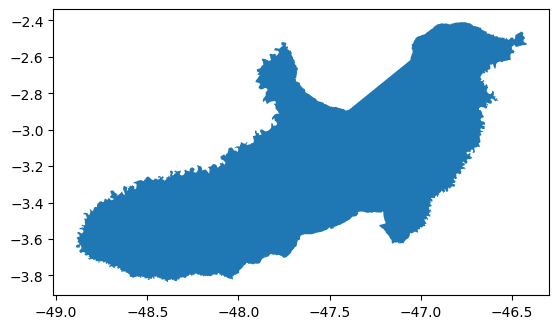

In [6]:
# Dicionário de códigos IBGE por UF
dict_uf = {
    'MT': '51', 'SP': '35', 'RJ': '33', 'MG': '31', 'AM': '13', 'PA': '15',
    'BA': '29', 'RS': '43', 'PR': '41', 'SC': '42', 'GO': '52', 'MS': '50',
    'TO': '17', 'RO': '11', 'AC': '12', 'RR': '14', 'AP': '16', 'MA': '21',
    'PI': '22', 'CE': '23', 'RN': '24', 'PB': '25', 'PE': '26', 'AL': '27',
    'SE': '28', 'DF': '53', 'ES': '32'
}

# Definir UF e município de interesse
uf = 'PA'
cod_uf = dict_uf[uf]
cod_mun = '1505502'  # Paragominas - PA
selecionando_muni = 'Paragominas'

# Obter malha municipal da UF
gdf_mun = obter_shapefile_municipios(uf)

# Garantir que o campo de comparação esteja em string
gdf_mun['codarea'] = gdf_mun['codarea'].astype(str)

# Filtrar município e criar uma cópia explícita para evitar SettingWithCopyWarning
gdf_shapefile = gdf_mun.loc[gdf_mun['codarea'] == cod_mun].copy()

# Validar se o município foi encontrado
if gdf_shapefile.empty:
    raise ValueError(f"Município com cod_mun='{cod_mun}' não encontrado para a UF '{uf}'.")

# Atribuir novos campos com segurança
gdf_shapefile.loc[:, 'NM_MUN'] = selecionando_muni
gdf_shapefile.loc[:, 'ID'] = 1
gdf_shapefile.loc[:, 'ID'] = gdf_shapefile['ID'].astype(int)

# Resetar índice, se desejar deixar o GeoDataFrame organizado
gdf_shapefile = gdf_shapefile.reset_index(drop=True)

gdf_shapefile.plot()

download_mapbiomas(
    output_dir="/content/mapbiomas_completo/",
    ano_inicio=1985,
    ano_fim=2024
)

# **Parte 3** - Geração dos resultados da Formação Florestal

0 arquivos .tif removidos do diretório de saída.
0 arquivos .tif removidos do diretório de saída.


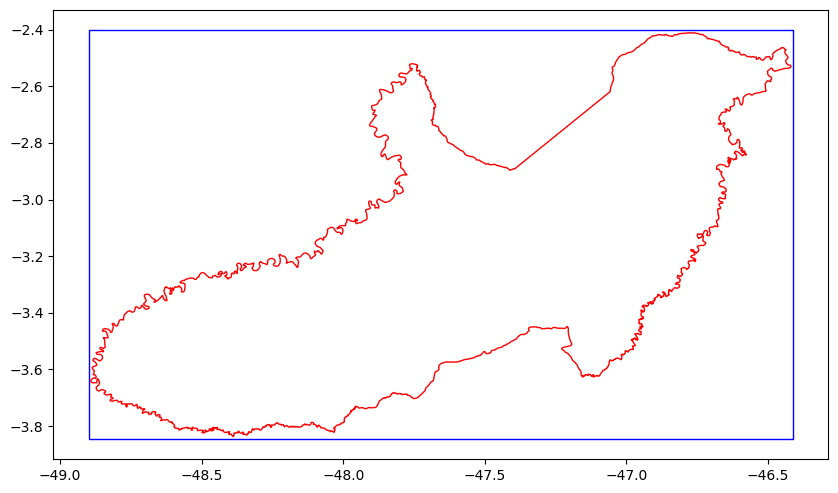

✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1985.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1986.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1987.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1988.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1989.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1990.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1991.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1992.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1993.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1994.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1995.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1996.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1997.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1998.tif
✅ Raster recortado com sucesso: /content/ROI/mb-brazil-v9-1999

In [7]:
# Define o caminho para o diretório de saída
caminho_saida = '/content/ROI/'

# Lista todos os arquivos .tif no diretório de saída
arquivos_tif = glob.glob(os.path.join(caminho_saida, '*.tif'))

# Remove os arquivos .tif
for arquivo in arquivos_tif:
    os.remove(arquivo)

print(f"{len(arquivos_tif)} arquivos .tif removidos do diretório de saída.")

# Define o caminho para o diretório de saída
caminho_saida = '/content/TEMP/'

# Lista todos os arquivos .tif no diretório de saída
arquivos_tif = glob.glob(os.path.join(caminho_saida, '*.tif'))

# Remove os arquivos .tif
for arquivo in arquivos_tif:
    os.remove(arquivo)

print(f"{len(arquivos_tif)} arquivos .tif removidos do diretório de saída.")

recortar_mapbiomas_por_roi(
    gdf_shapefile=gdf_shapefile,
    input_dir="/content/mapbiomas_completo/",
    output_dir="/content/ROI/",
    margem=0.008
)

#**Parte 4** -  Filtro de idade Florestal

In [8]:
# Define o caminho para o diretório de saída
caminho_saida = '/content/TEMP/'

# Lista todos os arquivos .tif no diretório de saída
arquivos_tif = glob.glob(os.path.join(caminho_saida, '*.tif'))

# Remove os arquivos .tif
for arquivo in arquivos_tif:
    os.remove(arquivo)

print(f"{len(arquivos_tif)} arquivos .tif removidos do diretório de saída.")

# Diretório onde os arquivos cortados serão salvos
output_dir = "/content/AGE/"

# Verifica se o diretório de saída existe, senão cria-o
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define o caminho para o diretório de saída
caminho_saida = '/content/AGE/'

# Lista todos os arquivos .tif no diretório de saída
arquivos_tif = glob.glob(os.path.join(caminho_saida, '*.tif'))

# Remove os arquivos .tif
for arquivo in arquivos_tif:
    os.remove(arquivo)

print(f"{len(arquivos_tif)} arquivos .tif removidos do diretório de saída.")

contagem = contar_ocorrencias_classe_rasters(
    input_folder="/content/ROI/",
    output_raster="/content/AGE/classe33_contagem.tif",
    classe=33
)

0 arquivos .tif removidos do diretório de saída.
0 arquivos .tif removidos do diretório de saída.
✅ Raster de contagem criado com sucesso: /content/AGE/classe33_contagem.tif


## Plotagem do Produto de idade florestal (total)

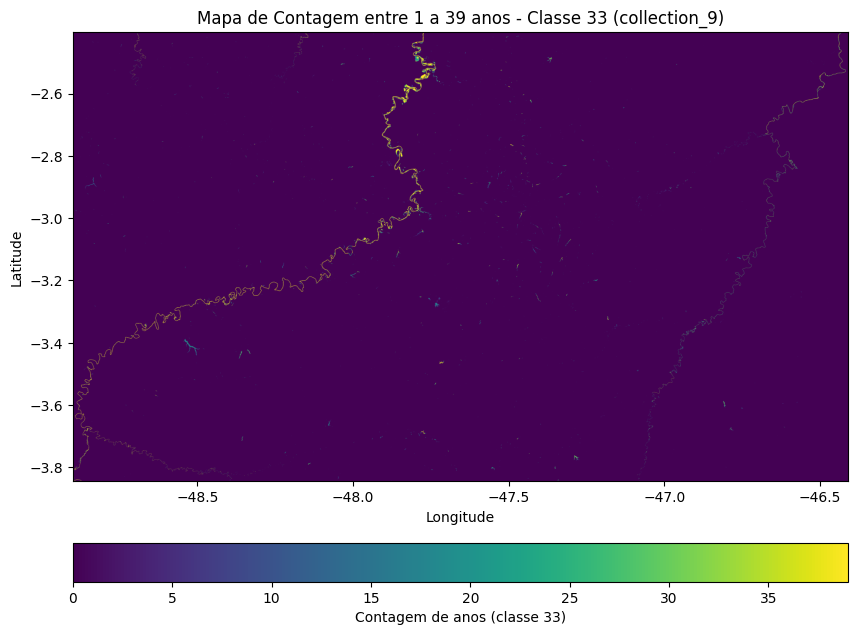

In [9]:
# Caminho para o raster de contagem
output_raster = "/content/AGE/classe33_contagem.tif"

# Carregar o raster
with rasterio.open(output_raster) as src:
    count_data = src.read(1)  # Ler a primeira banda
    crs = src.crs  # Sistema de referência
    extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)

# Criar o plot
plt.figure(figsize=(10, 8))
plt.imshow(count_data, cmap="viridis", extent=extent)
cbar = plt.colorbar(orientation="horizontal", pad=0.10)  # Legenda horizontal
cbar.set_label("Contagem de anos (classe 33)")
plt.title("Mapa de Contagem entre 1 a 39 anos - Classe 33 (collection_9)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Plotagem do Produto de idade florestal (cortado pelo municipio)

Raster recortado salvo em: /content/AGE/classe33_contagem_cortado.tif


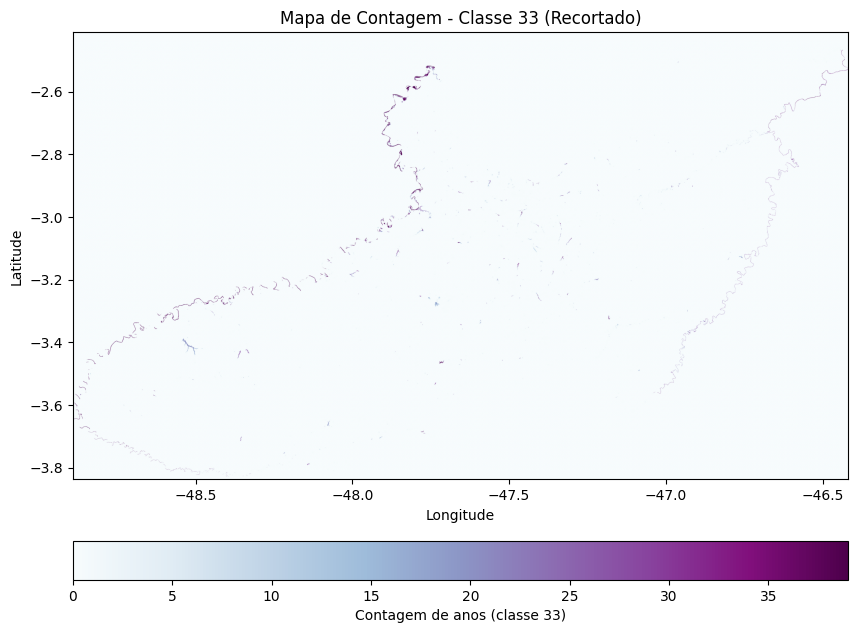

In [10]:
# Caminho para o raster de contagem
output_raster = "/content/AGE/classe33_contagem.tif"

# Caminho do shapefile ou GeoDataFrame
shapefile_path = "/content/drive/My Drive/BANKAI/SHP/BR_Municipios_2022.shp"  # Atualize conforme necessário
output_cropped_raster = "/content/AGE/classe33_contagem_cortado.tif"

# Carregar o shapefile como GeoDataFrame
gdf_shapefile = gpd.read_file(shapefile_path)

# Filtrar o shapefile para o recorte desejado (exemplo: Piracicaba)
filtered_geom = gdf_shapefile[gdf_shapefile["NM_MUN"] == selecionando_muni].geometry
if filtered_geom.empty:
    raise ValueError("Geometria do município de Piracicaba não encontrada no shapefile.")

# Recortar o raster
with rasterio.open(output_raster) as src:
    cropped_image, cropped_transform = mask(
        src, filtered_geom, crop=True, all_touched=True
    )
    cropped_meta = src.meta.copy()

# Atualizar metadados para o raster recortado
cropped_meta.update({
    "driver": "GTiff",
    "height": cropped_image.shape[1],
    "width": cropped_image.shape[2],
    "transform": cropped_transform
})

# Salvar o raster recortado
with rasterio.open(output_cropped_raster, "w", **cropped_meta) as dest:
    dest.write(cropped_image)

print(f"Raster recortado salvo em: {output_cropped_raster}")

# Visualizar o raster recortado
with rasterio.open(output_cropped_raster) as src:
    data = src.read(1)  # Ler a primeira banda
    extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)

plt.figure(figsize=(10, 8))
plt.imshow(data, cmap="BuPu", extent=extent)
cbar = plt.colorbar(orientation="horizontal", pad=0.10)  # Legenda horizontal
cbar.set_label("Contagem de anos (classe 33)")
plt.title("Mapa de Contagem - Classe 33 (Recortado)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Parte 5 - Processo por ID (vários polígonos)

936 arquivos .tif removidos de /content/ROI/.

▶ Processando ID_basin = 1
✅ Finalizado ID_basin = 1

▶ Processando ID_basin = 2
✅ Finalizado ID_basin = 2

▶ Processando ID_basin = 3
✅ Finalizado ID_basin = 3

▶ Processando ID_basin = 4
✅ Finalizado ID_basin = 4

▶ Processando ID_basin = 5
✅ Finalizado ID_basin = 5

▶ Processando ID_basin = 6
✅ Finalizado ID_basin = 6

▶ Processando ID_basin = 7
✅ Finalizado ID_basin = 7

▶ Processando ID_basin = 8
✅ Finalizado ID_basin = 8

▶ Processando ID_basin = 9
✅ Finalizado ID_basin = 9

▶ Processando ID_basin = 10
✅ Finalizado ID_basin = 10

▶ Processando ID_basin = 11
✅ Finalizado ID_basin = 11

▶ Processando ID_basin = 12
✅ Finalizado ID_basin = 12

▶ Processando ID_basin = 13
✅ Finalizado ID_basin = 13

▶ Processando ID_basin = 14
✅ Finalizado ID_basin = 14

▶ Processando ID_basin = 15
✅ Finalizado ID_basin = 15

▶ Processando ID_basin = 16
✅ Finalizado ID_basin = 16

▶ Processando ID_basin = 17
✅ Finalizado ID_basin = 17

▶ Processando ID_ba

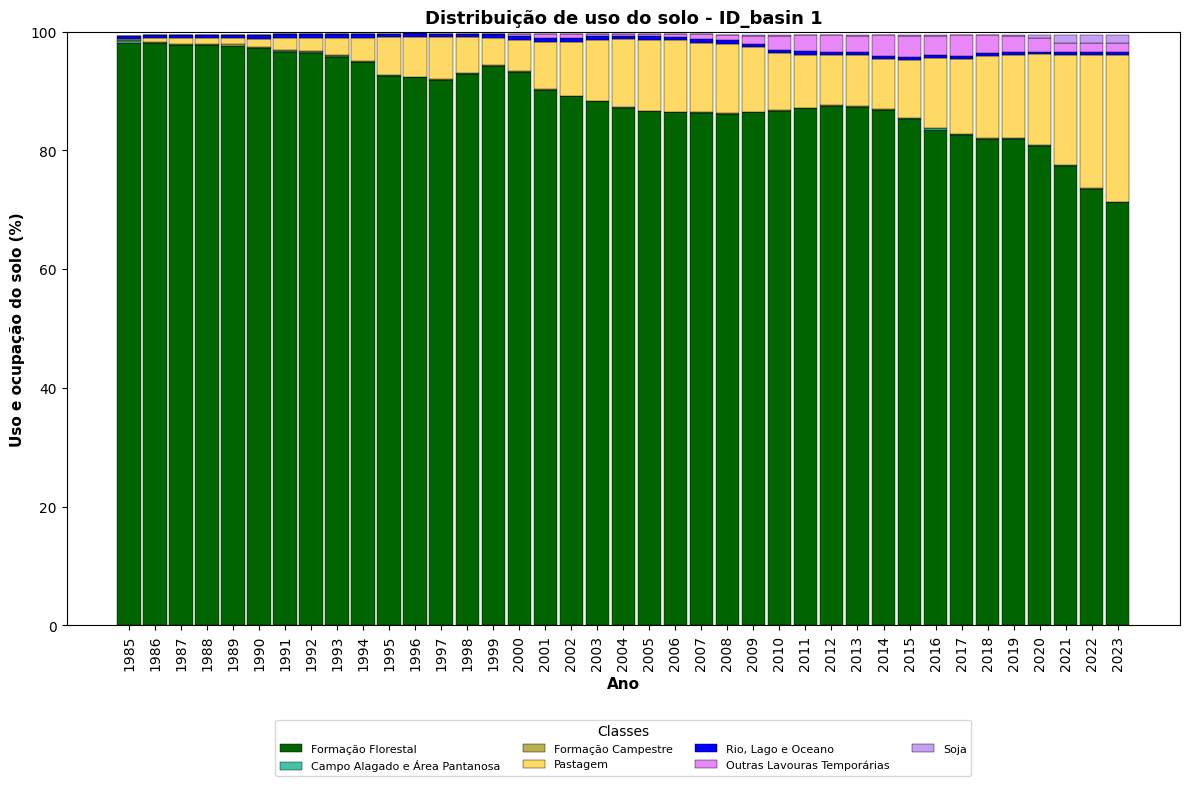

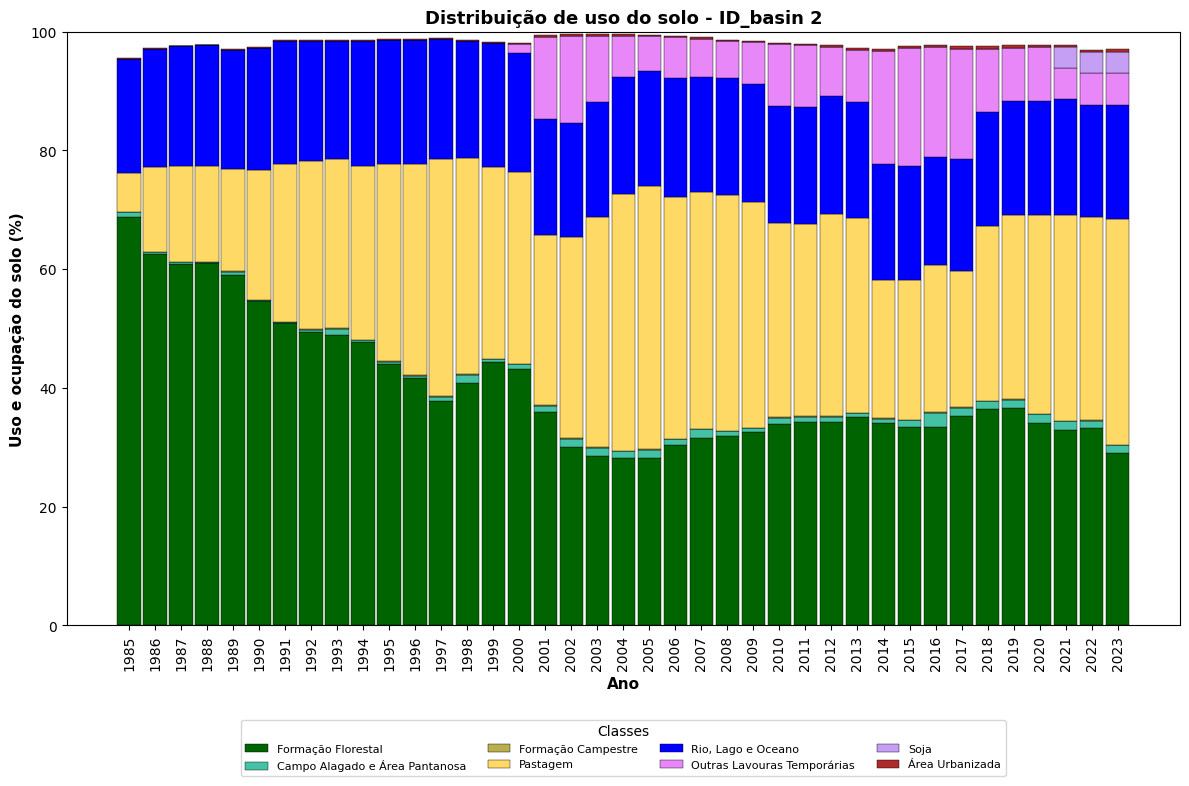

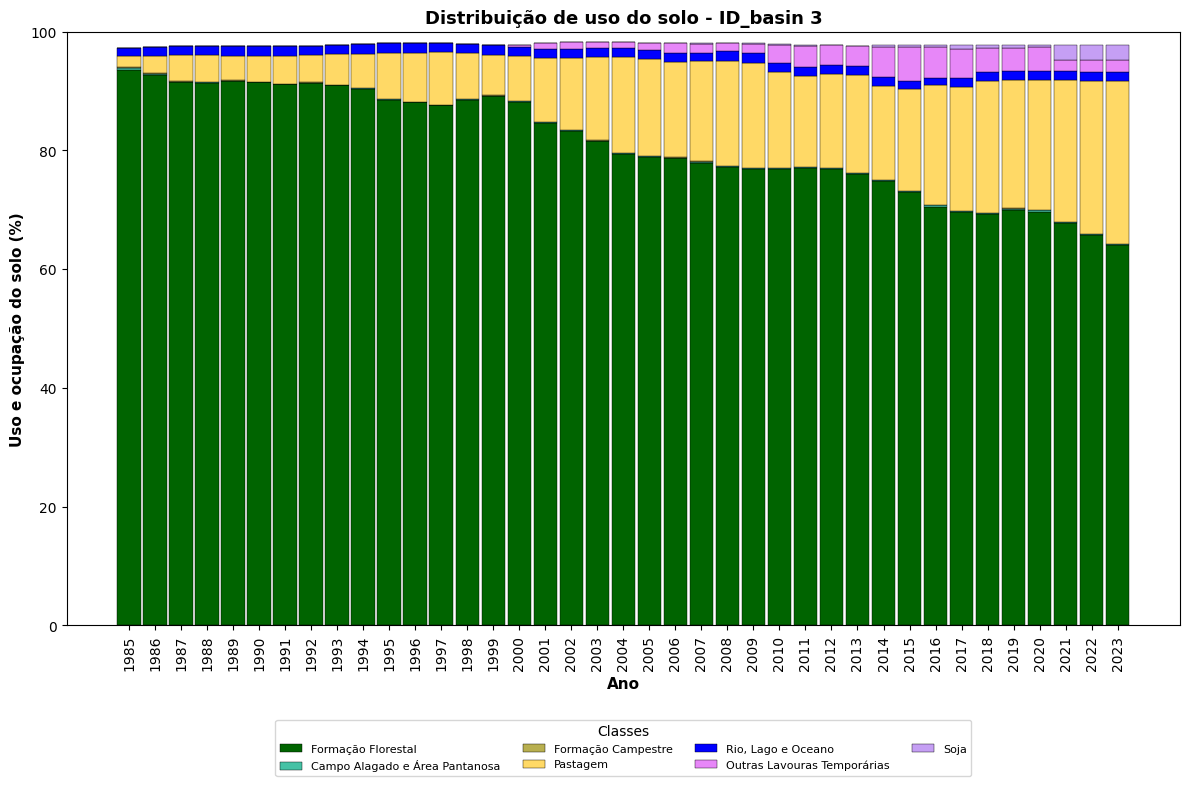

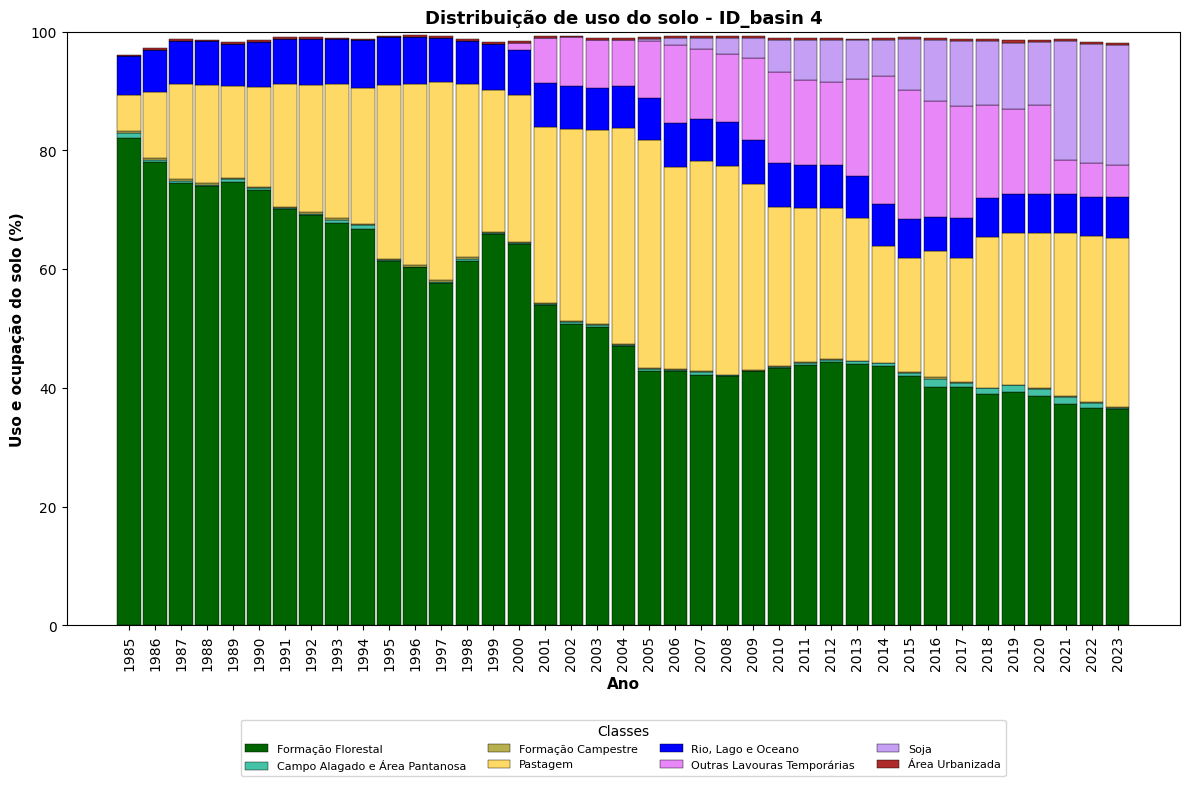

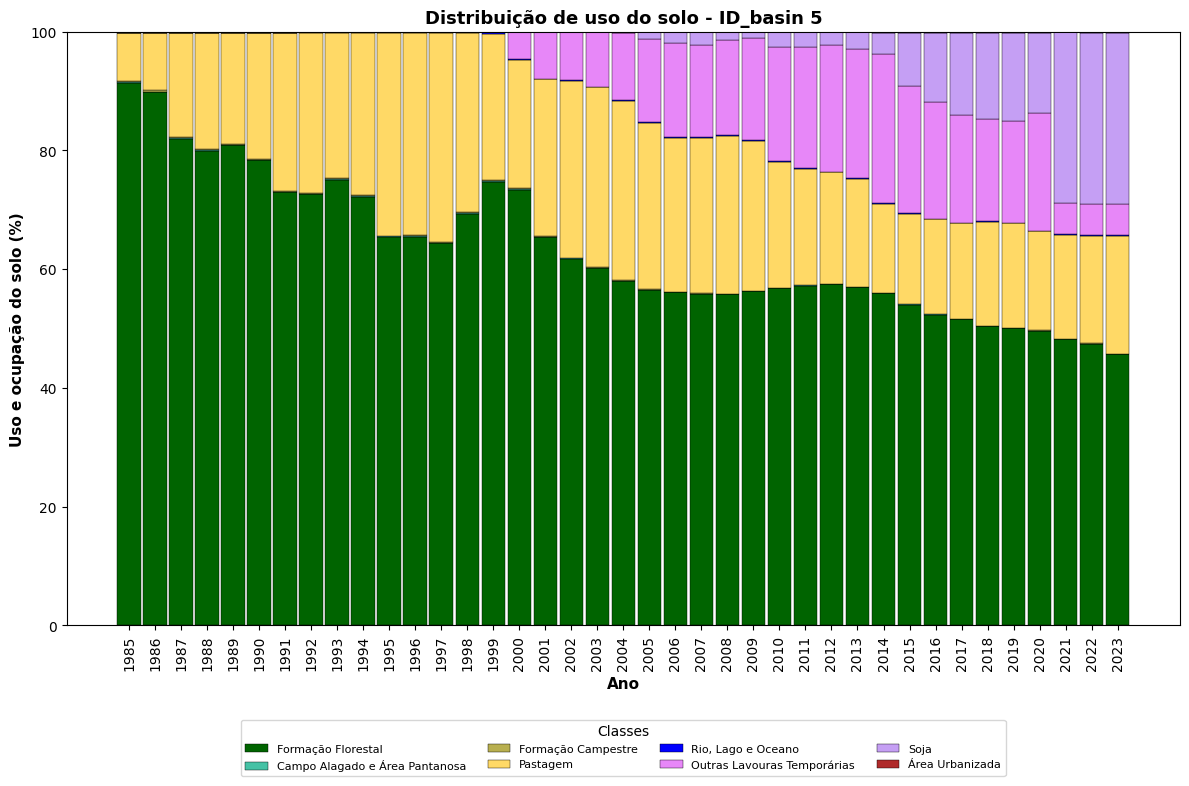

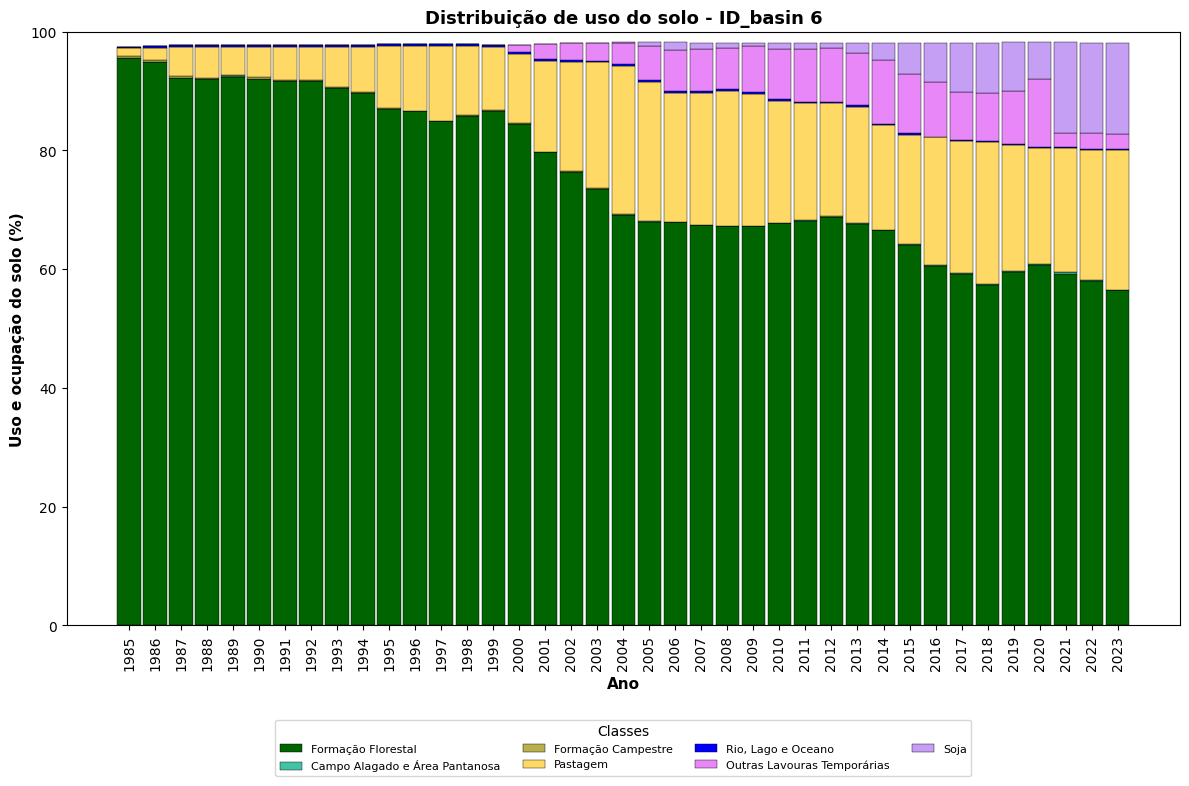

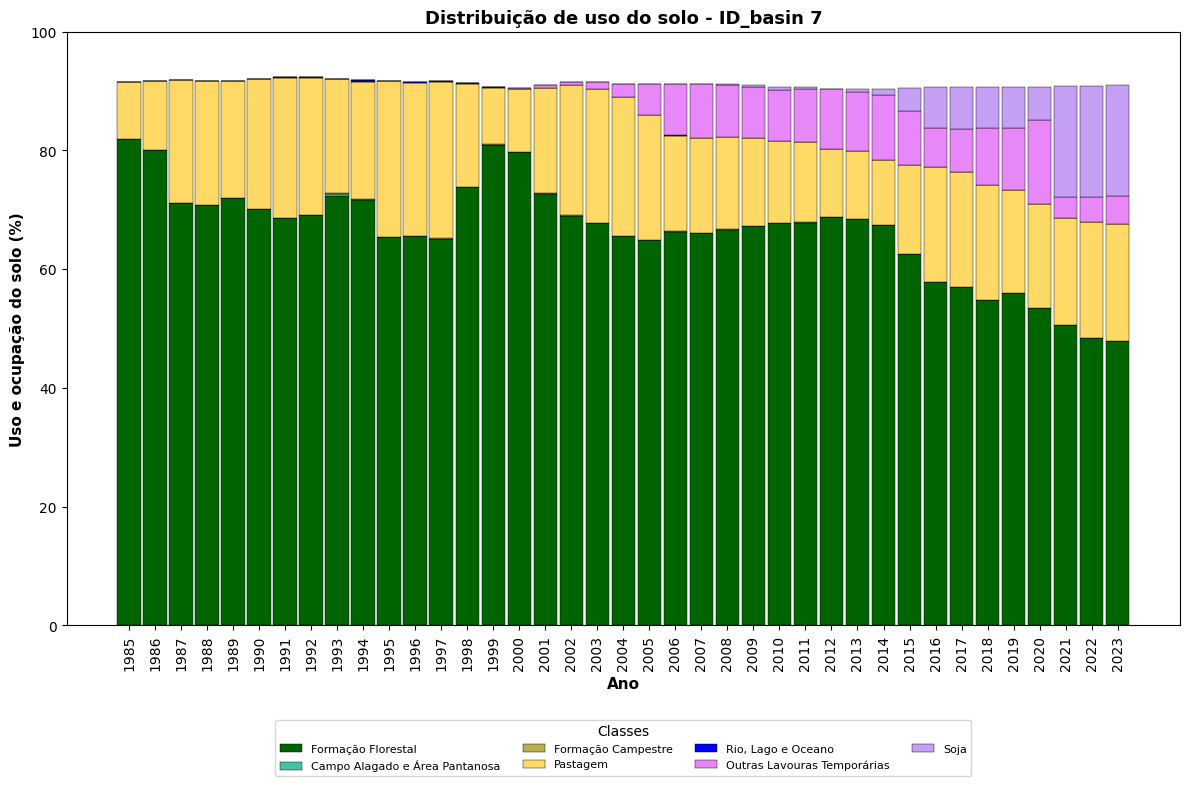

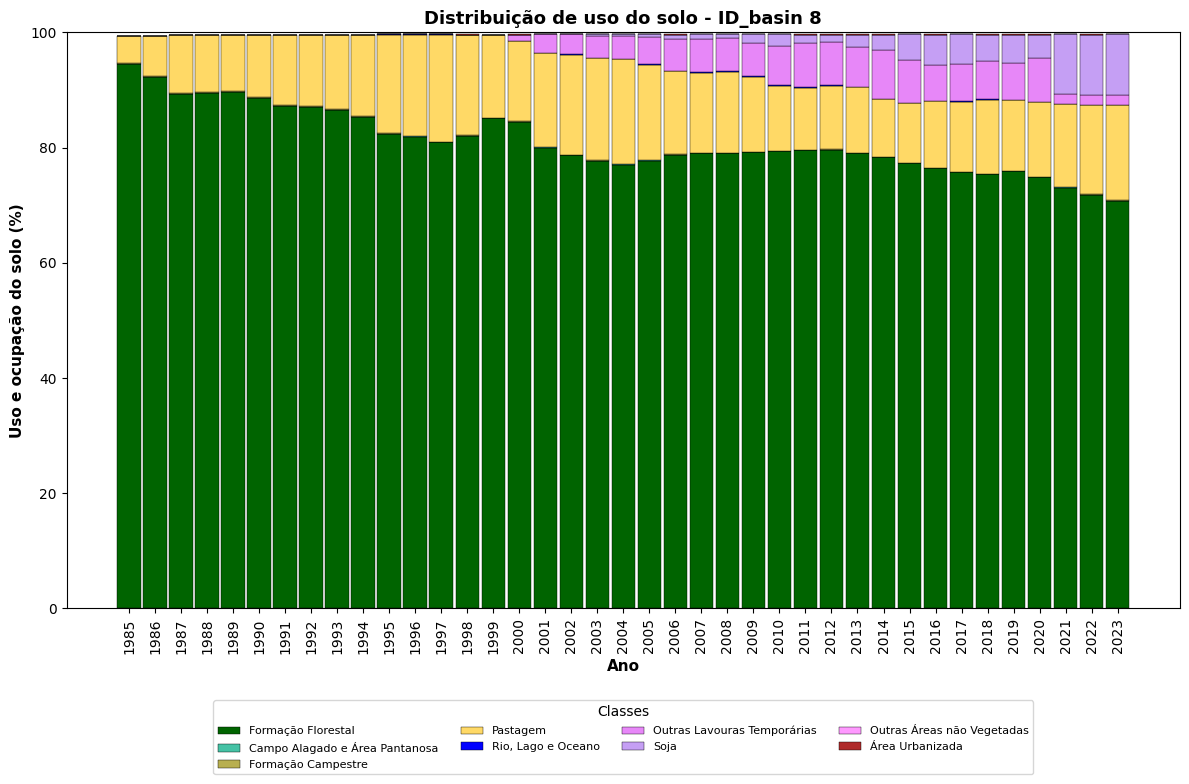

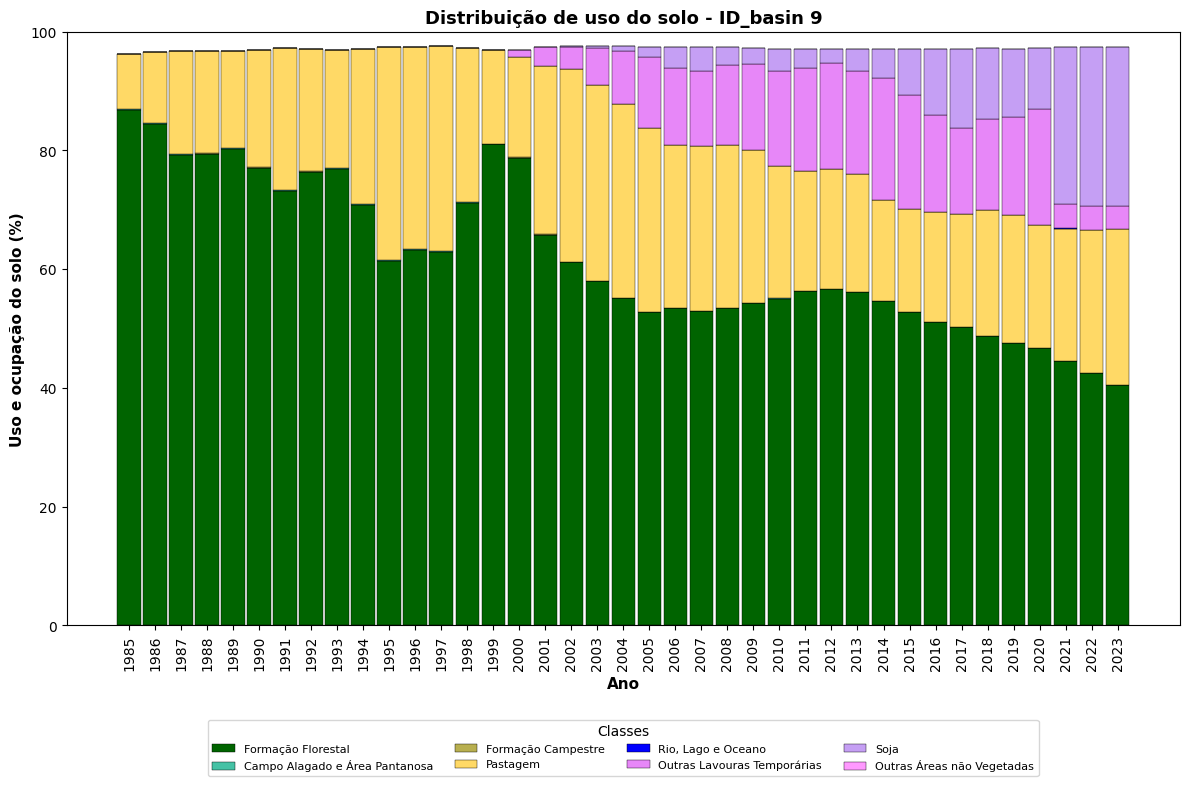

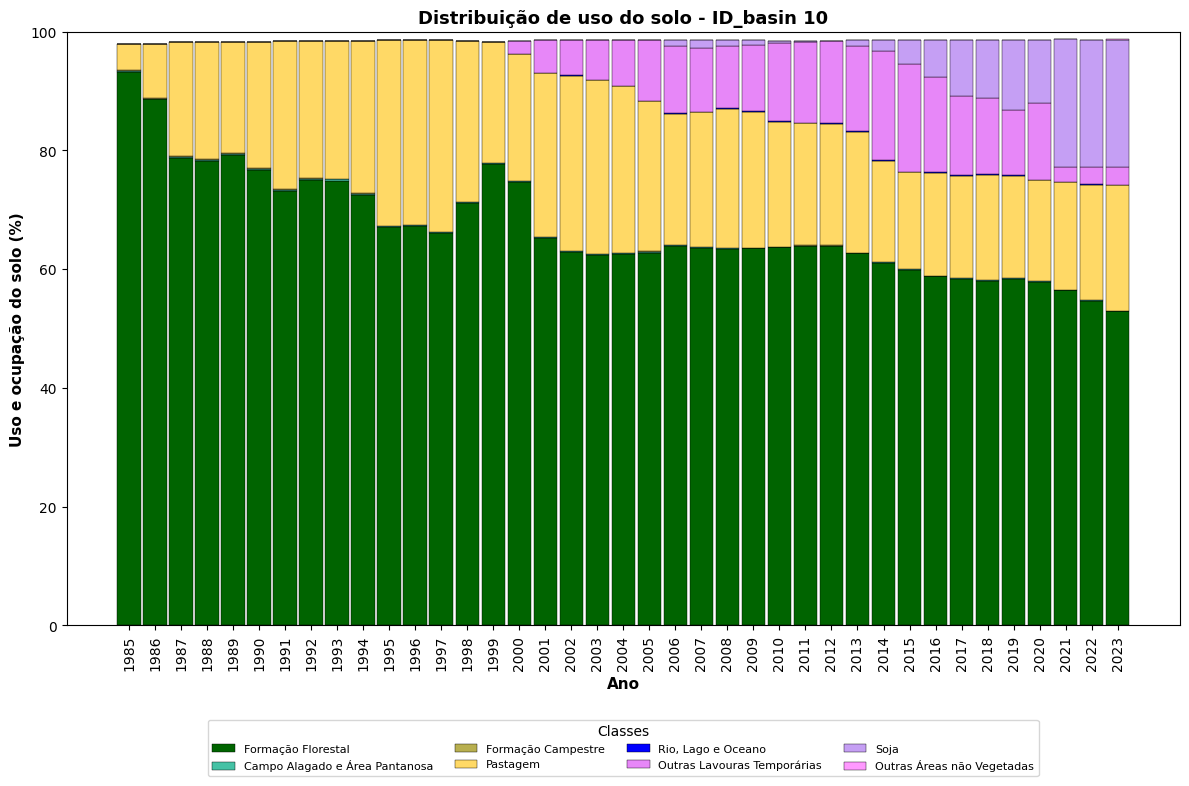

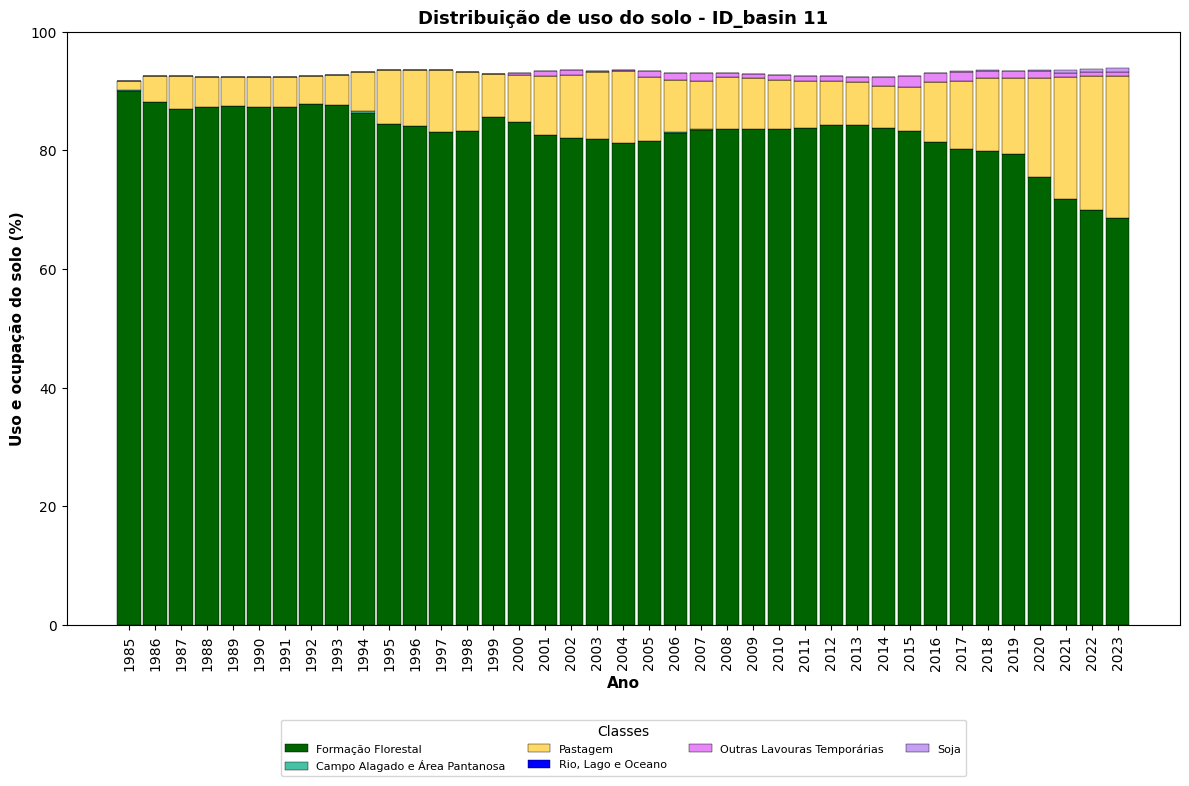

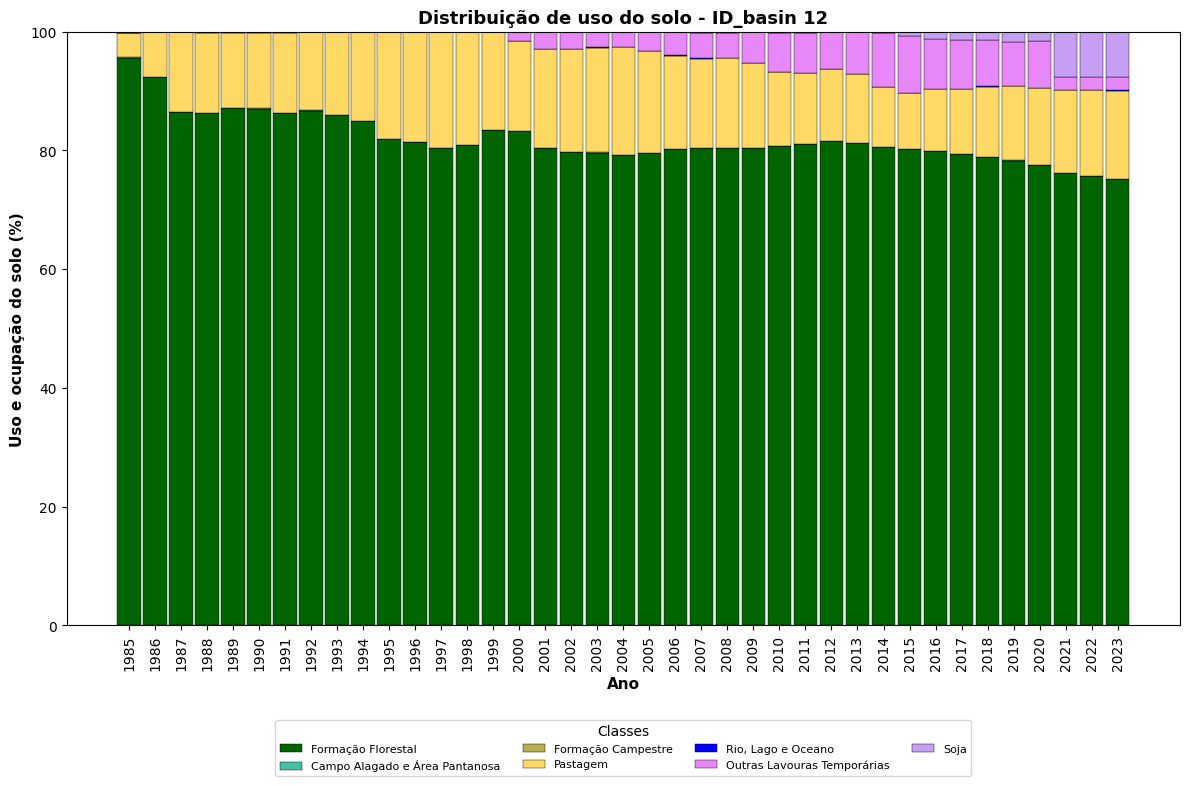

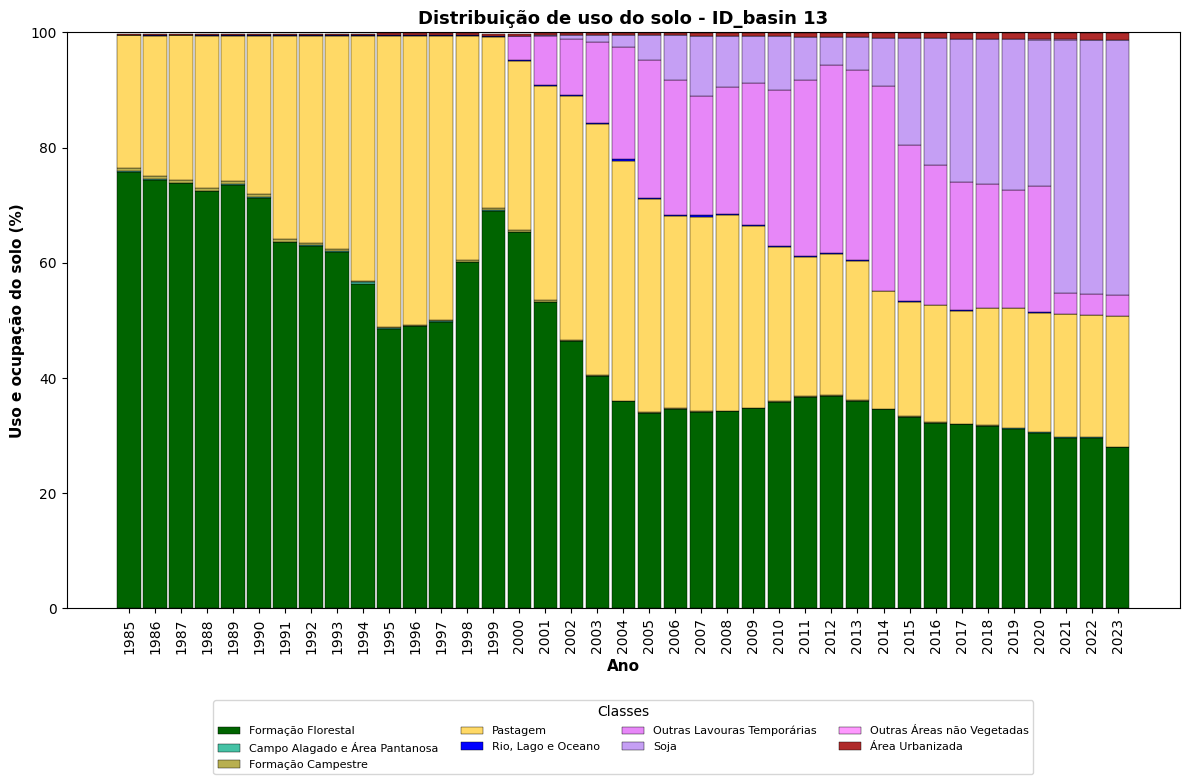

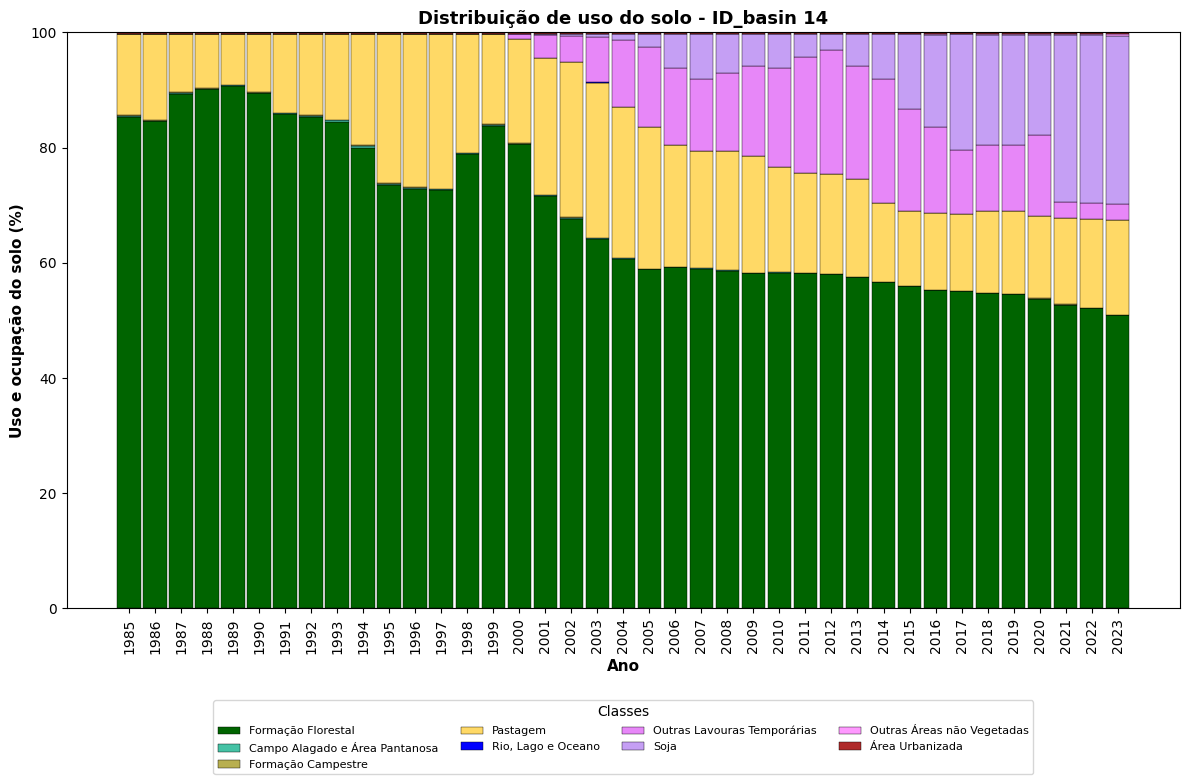

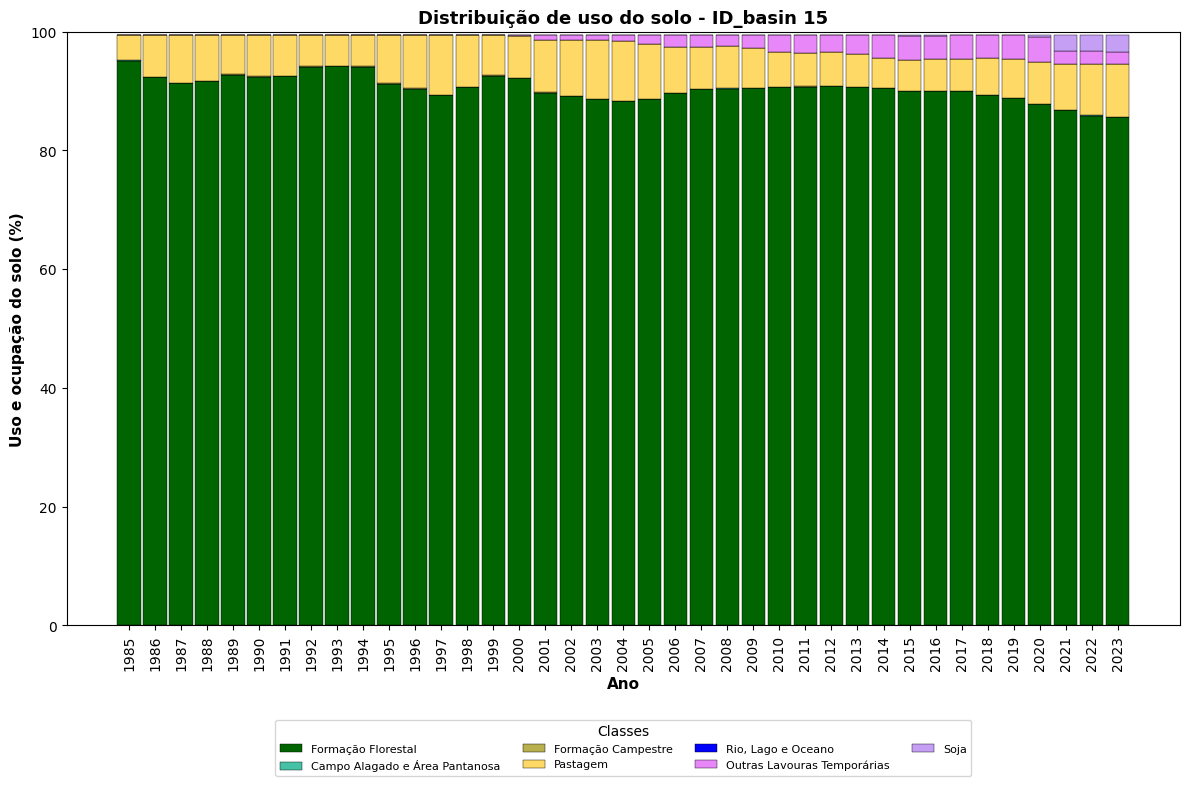

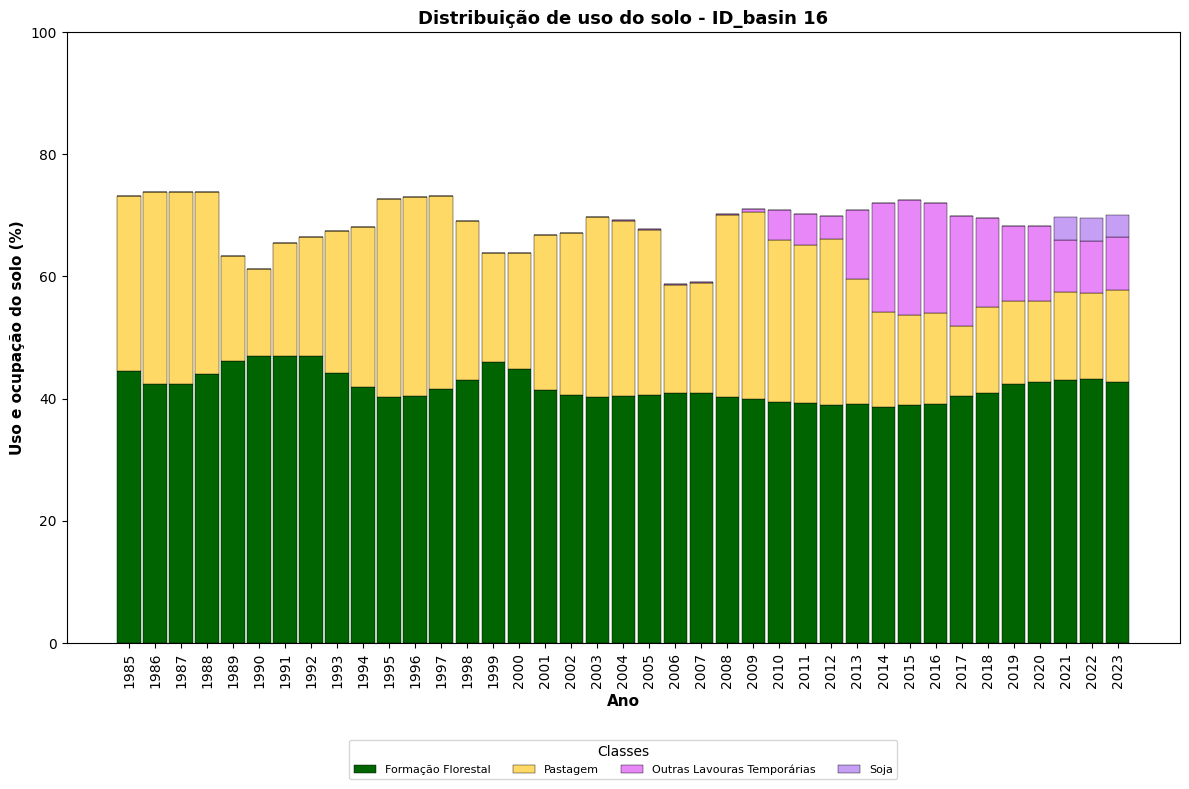

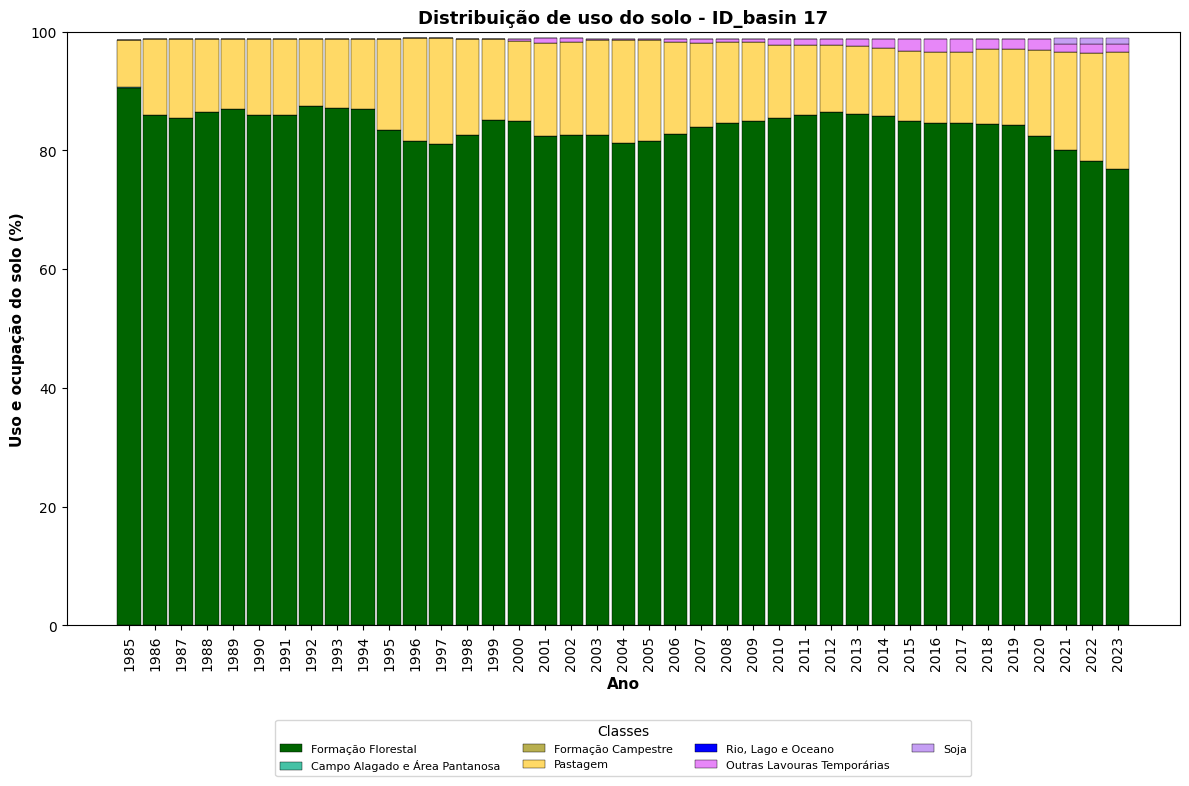

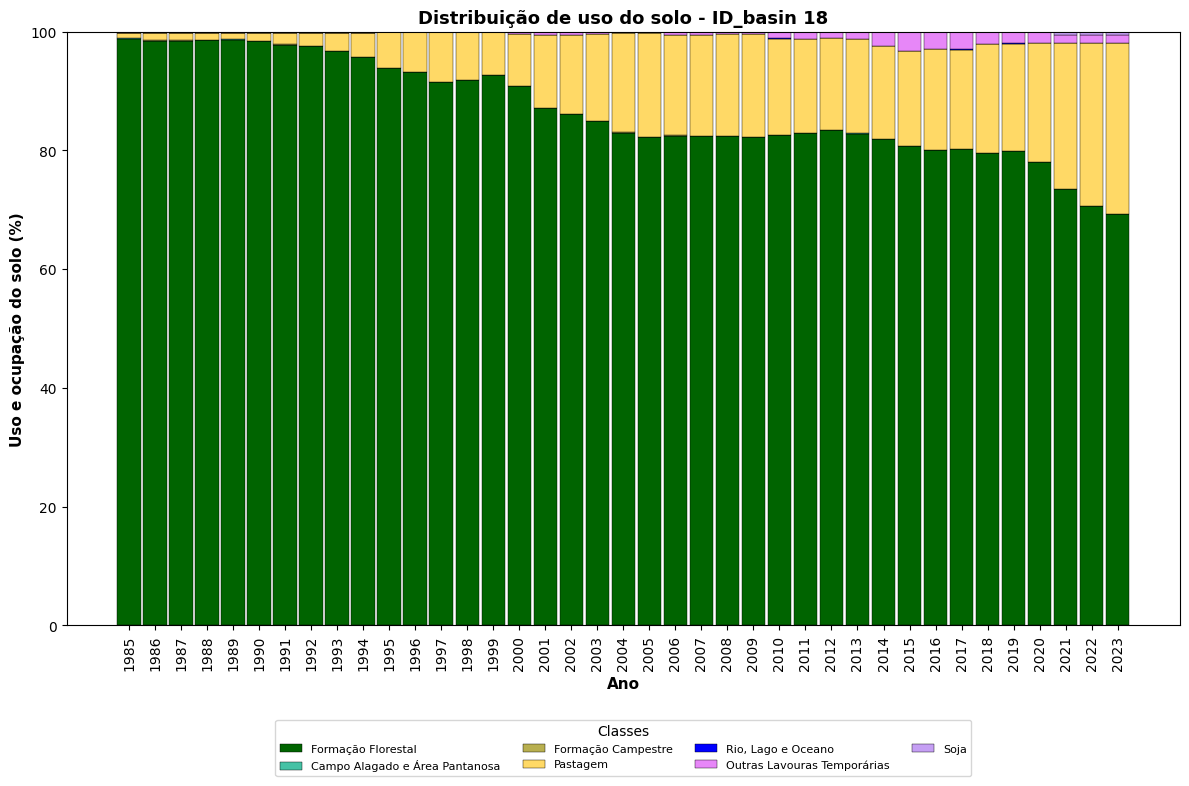

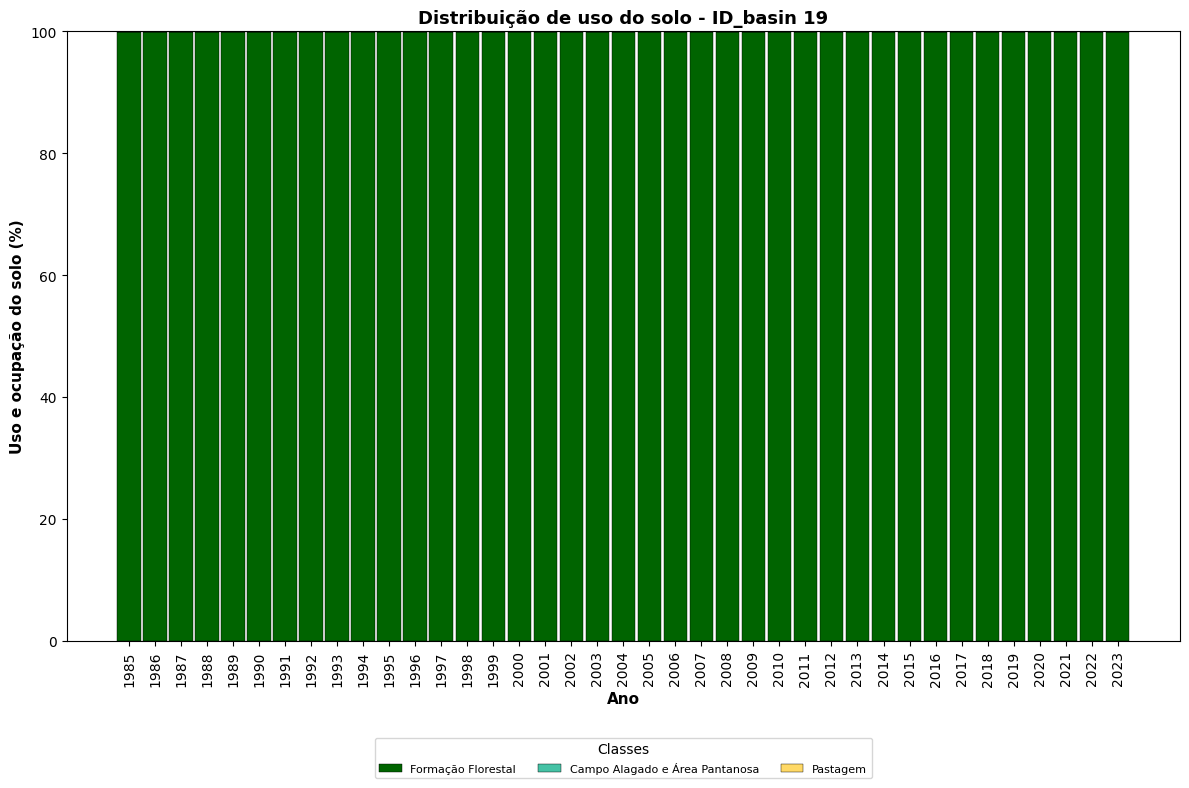

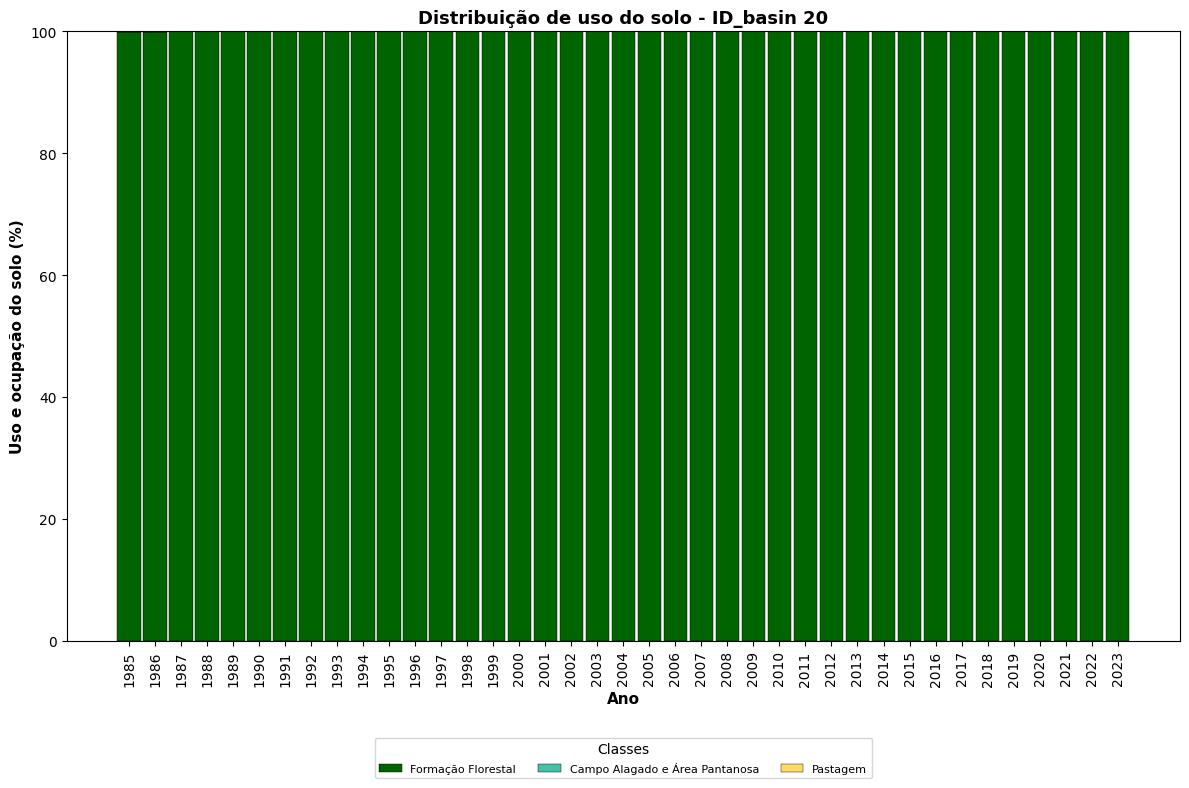

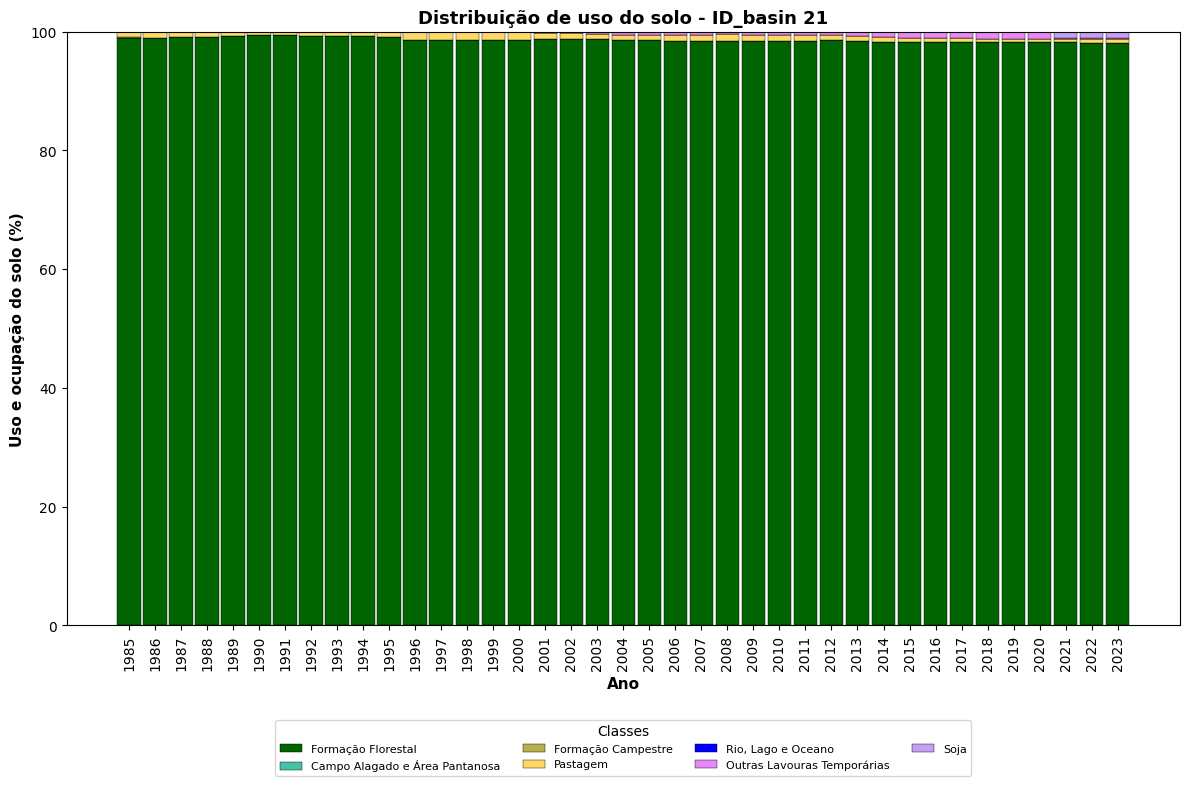

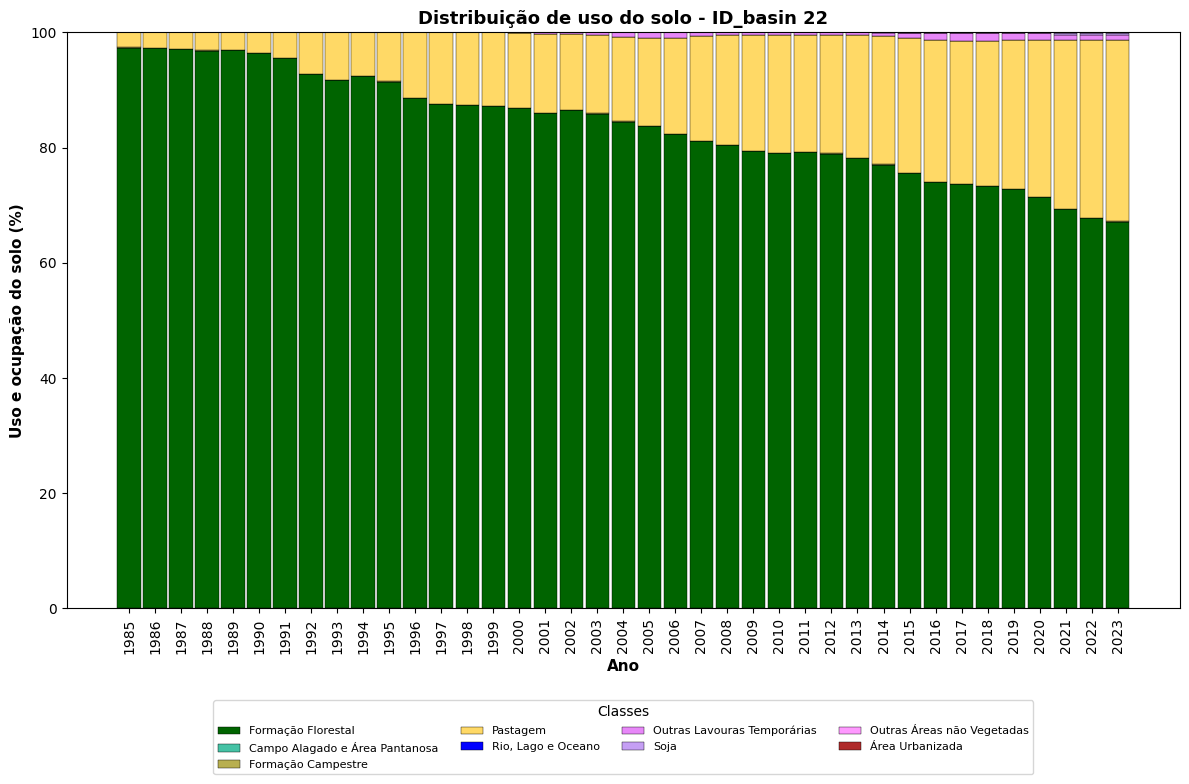

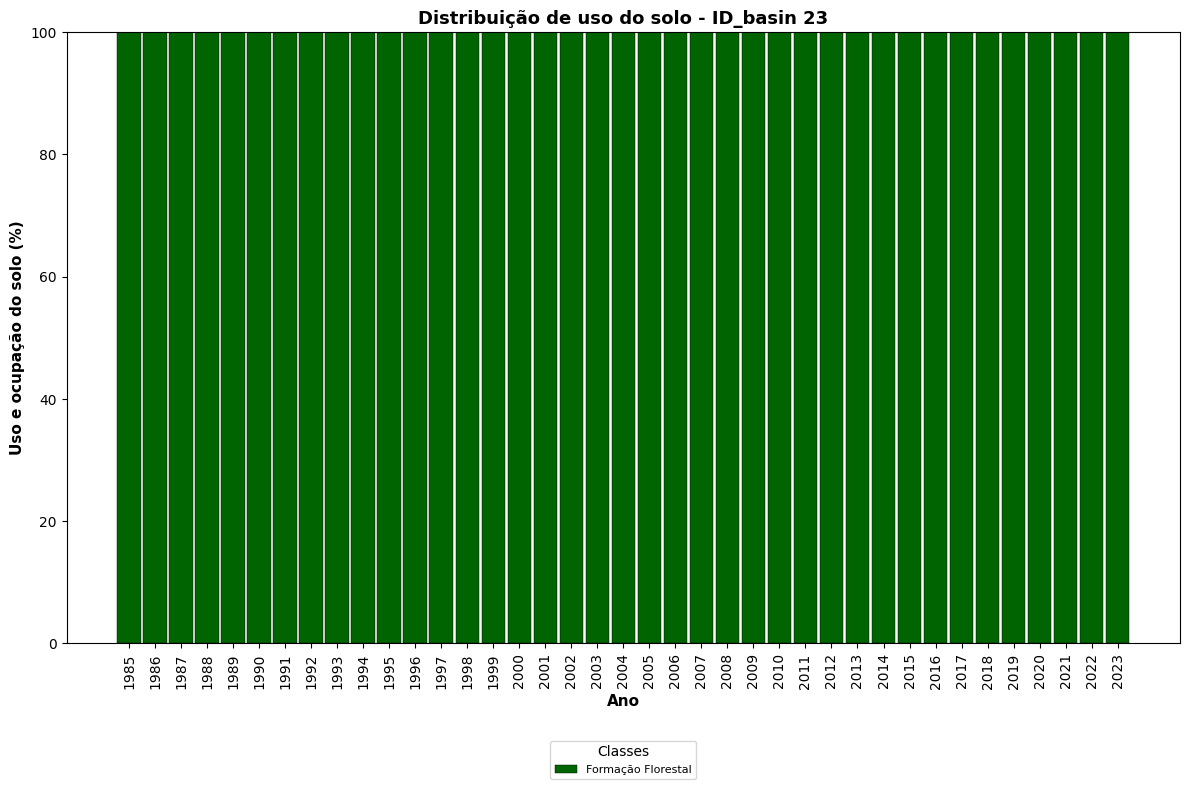

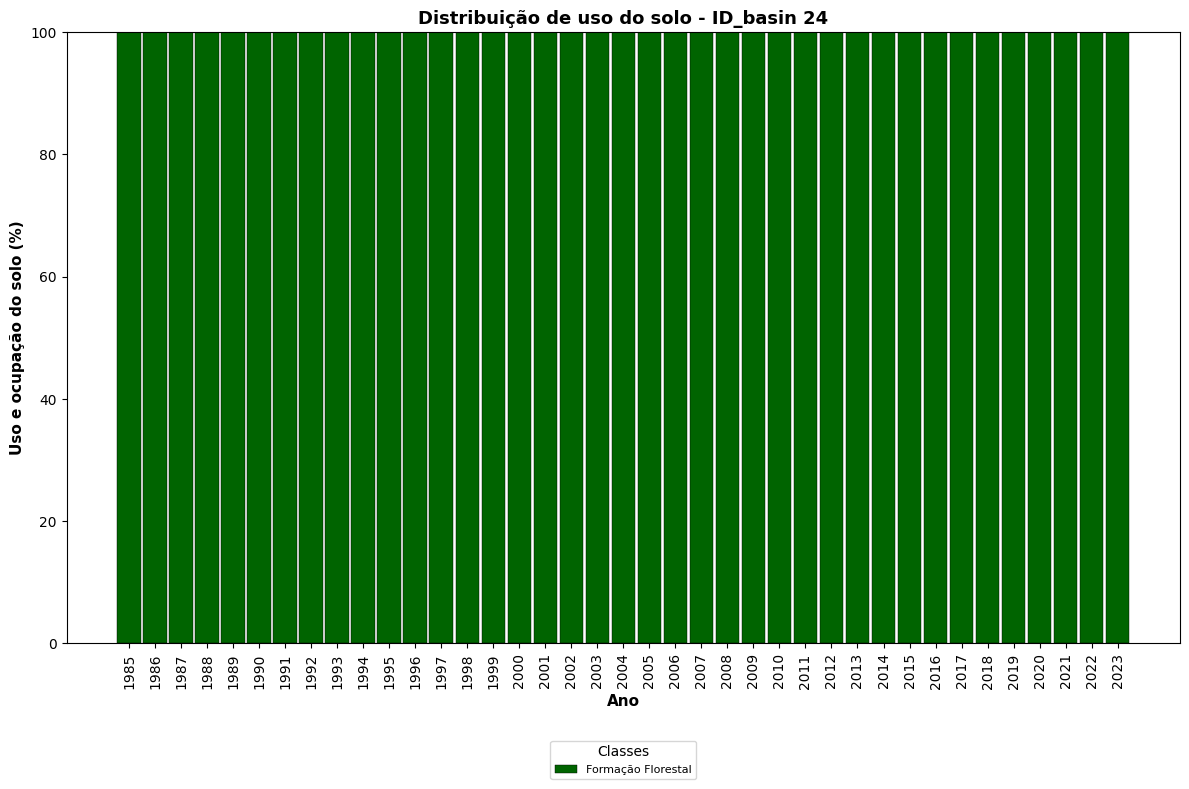

In [20]:
# =========================================================
# BLOCO COMPLEMENTAR AJUSTADO
# =========================================================

# USO COMPLEMENTAR por polígono

CAMINHO_SHAPEFILE_BACIAS = "/content/STM_bh_sheds_lv09.shp"
ID_COL = "ID_basin"

gdf_bacias = gpd.read_file(CAMINHO_SHAPEFILE_BACIAS)
gdf_bacias[ID_COL] = gdf_bacias[ID_COL].astype(int)
gdf_bacias = gdf_bacias.to_crs("EPSG:4326")

# Limpa somente a pasta ROI antes de gerar recortes por bacia
arquivos_tif = glob.glob(os.path.join("/content/ROI/", "*.tif"))
for arquivo in arquivos_tif:
    os.remove(arquivo)
print(f"{len(arquivos_tif)} arquivos .tif removidos de /content/ROI/.")

gerar_recortes_mapbiomas_por_bacia(
    gdf_base=gdf_bacias,
    id_col=ID_COL,
    input_dir="/content/mapbiomas_completo/",
    output_dir="/content/ROI/",
    ano_inicio=1985,
    ano_fim=2023,
    plotar=False,
    all_touched=False
)

df_freq_bacias = calcular_frequencia_pixels_por_unidade(
    caminho_imagens="/content/ROI/",
    id_col_saida=ID_COL,
    excluir_valores=[0]
)

print(df_freq_bacias.head())

df_freq_bacias.to_csv("/content/df_freq_bacias.csv", index=False)

df_long_bacias = exportar_tabela_longa_classes(
    df_freq=df_freq_bacias,
    id_col=ID_COL
)

df_long_bacias.to_csv("/content/df_freq_bacias_long.csv", index=False)

for basin_id in sorted(df_freq_bacias[ID_COL].unique()):
    plotar_uso_solo_por_unidade(
        df_freq=df_freq_bacias,
        unidade_id=basin_id,
        id_col=ID_COL,
        class_info=class_info,
        excluir_classes=[0]
    )